In [1]:
from pathlib import Path
import pandas as pd
import datetime as dt

from matplotlib import pyplot as plt

In [2]:
DIR2021 = Path(r'Q:\Data\Observed\Streets\Counts\CMP\2023\midblock')
DIR2023 = Path(r'Q:\Data\Observed\Streets\Counts\CMP\2023\midblock')
DIR2025 = Path(r'Q:\Data\Observed\Streets\Counts\CMP\2025\midblock')
OUTDIR = Path(r'Q:\CMP\LOS Monitoring 2025\cmp_counts\midblock')

In [3]:
def read_and_melt(indir, filename):
    df = pd.read_csv(indir / filename)

    m = df.melt(id_vars=['location_id_nodir','location_id_withdir','location','direction','date','dow','TIME'],
                value_vars=['00-15','15-30','30-45','45-60'],
                var_name='15min',
                value_name='count')

    m['date'] = pd.to_datetime(m['date'])
    m['datetime'] = m.apply(lambda x: dt.datetime(year=x['date'].year, 
                                                  month=x['date'].month, 
                                                  day=x['date'].day,
                                                  hour=int(x['TIME'].split(':')[0]),
                                                  minute=int(x['15min'].split('-')[0])), axis=1)
    return (m[['location_id_nodir',
               'location',
               'direction',
               'dow',
               'date',
               'datetime',
               'count']]
            .rename(columns={'location_id_nodir':'location_id',
                             'location':'location_name',
                             })
            .sort_values(['location_id',
                          'direction',
                          'datetime'])
            .reset_index(drop=True))

In [4]:
def rolling_sum(df, groupby, agg_field, hours=1):
    periods = hours * 4
    return (df.groupby(groupby)
              .rolling(periods)
              .agg({agg_field:'sum'})
              .shift(-1* (periods-1))
              .reset_index(level=groupby)
              .sort_index())[agg_field]

In [5]:
def min_time(df, groupby, min_field, time_field):
    return pd.merge(df.groupby(groupby)[min_field].idxmin(),
                    df[time_field],
                    left_on=min_field,
                    right_index=True)

In [6]:
def mean_time_from_datetime(*datetimes):
    date_part = dt.datetime(1900,1,1) 
    td_part = sum([dt.timedelta(hours=d.hour, minutes=d.minute) for d in datetimes], start=dt.timedelta(seconds=0)) / len(datetimes)
    datetime = date_part + td_part
    return datetime


In [7]:
def count_location_min_times(df):
    return pd.merge(min_time(df, 
                            groupby=['location_id','direction','date','dow'], 
                            min_field='1hour_count', 
                            time_field='datetime')
                   .rename(columns={'1hour_count':'1hour_idx',
                                    'datetime':'1hour_datetime'}),
                  min_time(df,
                           groupby=['location_id','direction','date','dow'],
                           min_field='3hour_count',
                           time_field='datetime')
                   .rename(columns={'3hour_count':'3hour_idx',
                                    'datetime':'3hour_datetime'}),
                  left_index=True, right_index=True)

In [8]:
df23 = read_and_melt(DIR2023, r'cmp_midblock_adt-2023-tuetothu-flat.csv')

In [9]:
df25 = read_and_melt(DIR2025, r'cmp_midblock_adt-2025-tuetothu-flat.csv')

In [10]:
total72hour = pd.merge(
    df23.groupby(['location_id','location_name','direction']).agg({'count':'sum'}),
    df25.groupby(['location_id','location_name','direction']).agg({'count':'sum'}),
    left_index=True, right_index=True,
    suffixes=['2023','2025']
)

In [11]:
total72hour['change'] = total72hour['count2025'] - total72hour['count2023']
total72hour['pct_change'] = total72hour['change'] / total72hour['count2023']

In [12]:
total72hour

count2023  \
location_id location_name                                      direction              
1           19TH AVE BETWEEN MORAGA AND NORIEGA                NB             87533   
                                                               SB             71270   
2           1ST ST BETWEEN MISSION AND MINNA                   SB             58321   
3           3RD ST BETWEEN FITZGERALD AND GILMAN               NB             27203   
                                                               SB             24853   
4           3RD ST BETWEEN MINNA AND HOWARD                    NB             79191   
5           4TH ST BETWEEN MINNA AND HOWARD                    SB             45739   
6           7TH ST BETWEEN HOWARD AND FOLSOM                   NB             43141   
7           8TH ST BETWEEN TEHAMA AND CELEMENTINA              SB             34882   
8           COLUMBUS AVE BETWEEN BROADWAY AND PACIFIC          NB             21373   
                                                               SB             26735   
9           FREMONT ST BETWEEN MISSION AND NATOMA              NB             65858   
10          JUNIPERO SERRA BLVD BETWEEN FONT AND BROTHERHOO... NB            125355   
                                                               SB            136516   
11          MISSION ST BETWEEN 24TH AND 25TH                   NB             16183   
                                                               SB             23133   
12          SAN JOSE AVE BETWEEN RANDALL AND SAINT MARY'S      NB             52450   
                                                               SB             51102   
13          THE EMBARCADERO BETWEEN BROADWAY AND WASHINGTON    NB             37040   
                                                               SB             44367   
14          VAN NESS AVE BETWEEN CALIFORNIA AND PINE           NB             30868   
                                                               SB             37552   
15          BAY ST BETWEEN LEAVENWORTH AND COLUMBUS            EB             26911   
                                                               WB             25755   
16          BROADWAY TUNNEL BETWEEN LARKIN AND POWELL          EB             48019   
                                                               WB             29701   
17          BRYANT ST BETWEEN 4TH AND 3RD                      EB             46722   
18          BUSH ST BETWEEN GRANT AND KEARNY                   EB             41709   
19          BUSH ST BETWEEN VAN NESS AND POLK                  EB             48865   
20          CESAR CHAVEZ ST BETWEEN YORK AND HAMPSHIRE         EB             63253   
                                                               WB             75208   
21          FELL ST BETWEEN DIVISADERO AND SCOTT               WB             78394   
22          GEARY BLVD BETWEEN LAGUNA AND GOUGH                EB             36720   
                                                               WB             38250   
23          GOLDEN GATE AVE BETWEEN VAN NESS AND POLK          EB             17896   
24          HARRISON ST BETWEEN 4TH AND 3RD                    WB             42393   
25          LOMBARD ST BETWEEN BRODERICK AND DIVISADERO        EB             67734   
                                                               WB             60186   
26          OAK ST BETWEEN DIVISADERO AND SCOTT                EB             76169   
27          PINE ST BETWEEN GRANT AND KEARNY                   WB             49152   
28          PINE ST BETWEEN VAN NESS AND POLK                  WB             55666   
29          TURK ST BETWEEN VAN NESS AND POLK                  WB             20632   

                                                                          count2025  \
location_id location_name                                      direction              
1           19TH AVE BETWEEN MORAGA AND NORIEGA                NB      

In [13]:
df23['1hour_count'] = rolling_sum(df23, ['location_id','direction'], 'count', 1)
df23['3hour_count'] = rolling_sum(df23, ['location_id','direction'], 'count', 3)
df25['1hour_count'] = rolling_sum(df25, ['location_id','direction'], 'count', 1)
df25['3hour_count'] = rolling_sum(df25, ['location_id','direction'], 'count', 3)

In [14]:
min23 = count_location_min_times(df23)
min25 = count_location_min_times(df25)

In [15]:
p23_1 = min23.pivot_table(index=['location_id','direction'], columns='dow', values='1hour_datetime')
p23_1['1hour_mean'] = p23_1.apply(lambda x: mean_time_from_datetime(*x), axis=1)
p23_1['1hour_mean_flag'] = 1* (~p23_1['1hour_mean'].between(dt.datetime(1900,1,1,1,45), dt.datetime(1900,1,1,3,15)))
p23_3 = min23.pivot_table(index=['location_id','direction'], columns='dow', values='3hour_datetime')
p23_3['3hour_mean'] = p23_3.apply(lambda x: mean_time_from_datetime(*x), axis=1)
p23_3['3hour_mean_flag'] = 1* (~p23_3['3hour_mean'].between(dt.datetime(1900,1,1,0,45), dt.datetime(1900,1,1,1,15)))

In [16]:
p25_1 = min25.pivot_table(index=['location_id','direction'], columns='dow', values='1hour_datetime')
p25_1['1hour_mean'] = p25_1.apply(lambda x: mean_time_from_datetime(*x), axis=1)
p25_1['1hour_mean_flag'] = 1* (~p25_1['1hour_mean'].between(dt.datetime(1900,1,1,2), dt.datetime(1900,1,1,3,30)))
p25_3 = min25.pivot_table(index=['location_id','direction'], columns='dow', values='3hour_datetime')
p25_3['3hour_mean'] = p25_3.apply(lambda x: mean_time_from_datetime(*x), axis=1)
p25_3['3hour_mean_flag'] = 1* (~p25_3['3hour_mean'].between(dt.datetime(1900,1,1,0,45), dt.datetime(1900,1,1,1,15)))

In [17]:
hr1 = pd.merge(p23_1, p25_1, left_index=True, right_index=True, suffixes=['_2023','_2025'])
hr3 = pd.merge(p23_3, p25_3, left_index=True, right_index=True, suffixes=['_2023','_2025'])

In [18]:
hr1['diff_flag'] = 1 * (hr1['1hour_mean_2025'] - hr1['1hour_mean_2023']).map(lambda x: x.total_seconds() > 45*60)
hr3['diff_flag'] = 1 * (hr3['3hour_mean_2025'] - hr3['3hour_mean_2023']).map(lambda x: x.total_seconds() > 30*60)

In [19]:
hr1.to_csv(OUTDIR / 'qc_1hr.csv')
hr3.to_csv(OUTDIR / 'qc_3hr.csv')

In [20]:
df23.to_csv(OUTDIR / 'cmp_counts_2023.csv', index=False)
df25.to_csv(OUTDIR / 'cmp_counts_2025.csv', index=False)

In [21]:
df23['time'] = df23['datetime'].map(lambda x: x.time())
df25['time'] = df25['datetime'].map(lambda x: x.time())

In [22]:
comp = pd.merge((df23.groupby(['location_id','direction','time'], as_index=False)
                 .agg({'count':'mean','1hour_count':'mean','3hour_count':'mean'})
                 .rename(columns={'count':'count2023','1hour_count':'1hour2023','3hour_count':'3hour2023'})),
                (df25.groupby(['location_id','direction','time'], as_index=False)
                 .agg({'count':'mean','1hour_count':'mean','3hour_count':'mean'})
                 .rename(columns={'count':'count2025','1hour_count':'1hour2025','3hour_count':'3hour2025'})))

In [23]:
comp

,location_id,direction,time,count2023,1hour2023,3hour2023,count2025,1hour2025,3hour2025
0,1,NB,00:00:00,88.666667,369.000000,724.666667,86.666667,283.333333,504.666667
1,1,NB,00:15:00,111.000000,350.000000,665.333333,74.000000,241.333333,437.333333
2,1,NB,00:30:00,81.666667,302.333333,584.000000,58.000000,202.000000,386.000000
3,1,NB,00:45:00,87.666667,268.000000,539.666667,64.666667,174.666667,346.666667
4,1,NB,01:00:00,69.666667,226.000000,494.000000,44.666667,135.000000,311.666667
...,...,...,...,...,...,...,...,...,...
4027,29,WB,22:45:00,36.333333,128.000000,229.000000,48.666667,190.000000,311.000000
4028,29,WB,23:00:00,34.666667,112.000000,198.000000,44.000000,167.666667,275.500000
4029,29,WB,23:15:00,30.666667,85.000000,178.500000,57.666667,136.500000,247.500000
4030,29,WB,23:30:00,26.333333,77.000000,164.500000,39.666667,99.500000,197.000000


In [24]:
#comp.to_csv(OUTDIR / 'compare_2023_2025.csv', index=False)

In [25]:
comp['30min'] = comp['time'].map(lambda x: dt.time(hour=x.hour,
                                                   minute=0 if x.minute < 30 else 30
                                                   )
                                )
comp['60min'] = comp['time'].map(lambda x: dt.time(hour=x.hour))

In [26]:
comp30 = (
    comp
     .groupby(['location_id','direction','30min'], as_index=False)
     .agg({'count2023':'sum',
           'count2025':'sum',
           '1hour2023':'first',
           '1hour2025':'first',
           '3hour2023':'first',
           '3hour2025':'first'})
)

In [27]:
comp60 = (
    comp
     .groupby(['location_id','direction','60min'], as_index=False)
     .agg({'count2023':'sum',
           'count2025':'sum',
           '1hour2023':'first',
           '1hour2025':'first',
           '3hour2023':'first',
           '3hour2025':'first'})
)

In [28]:
locations = df23[['location_id','location_name','direction']].drop_duplicates().set_index(['location_id','direction'])

C:\Users\drew\AppData\Local\Temp\ipykernel_61584\3708991123.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


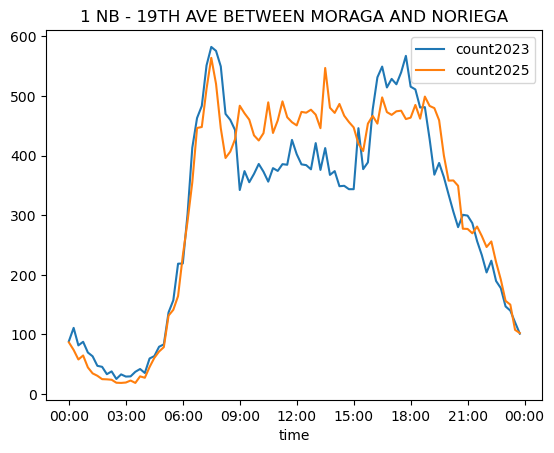

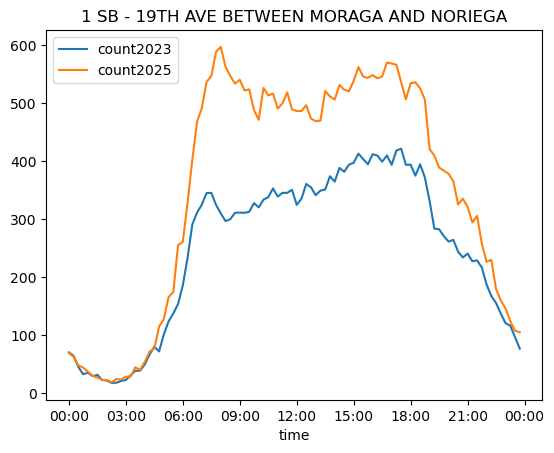

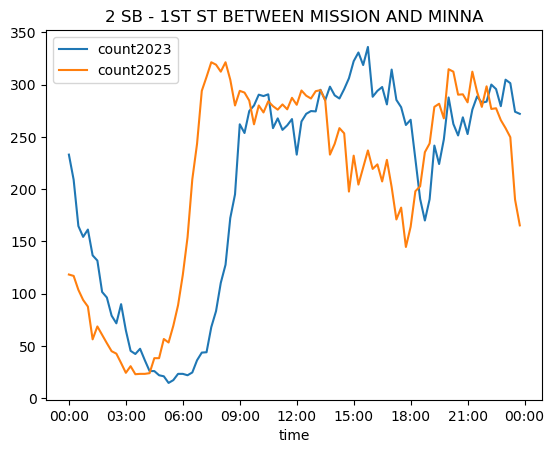

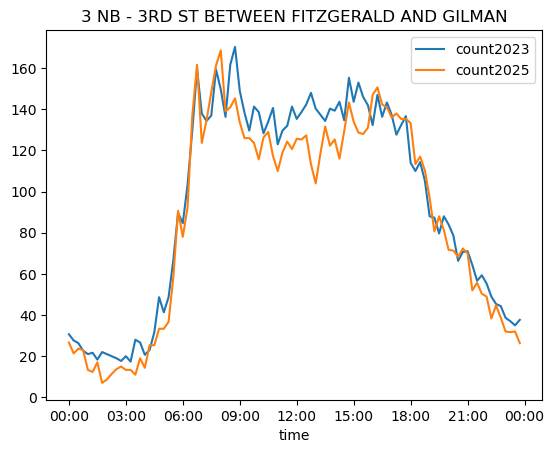

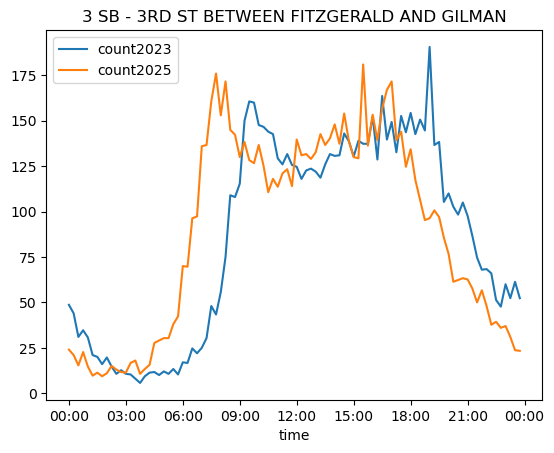

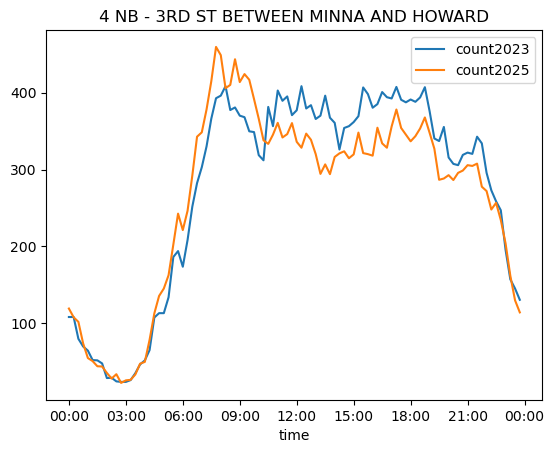

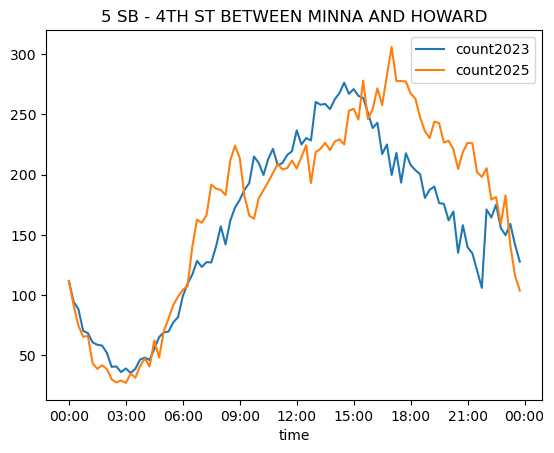

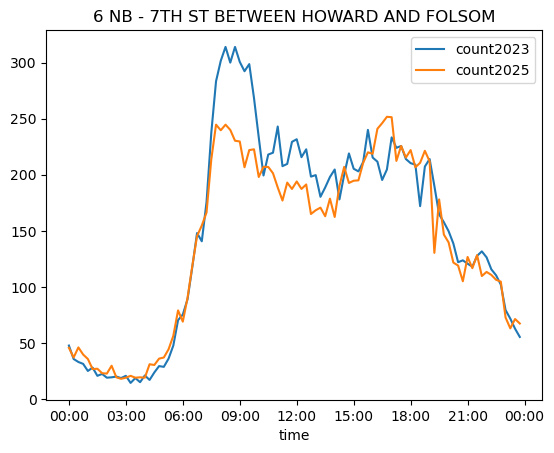

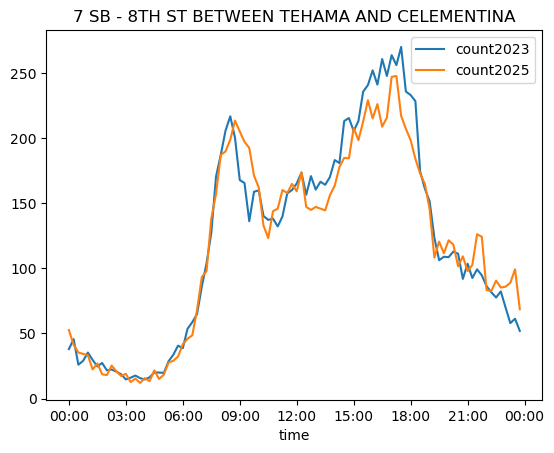

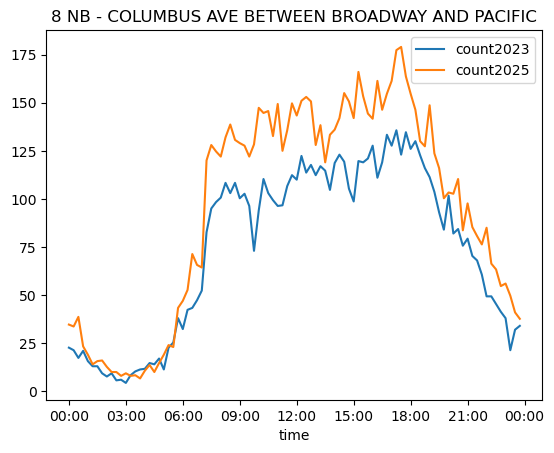

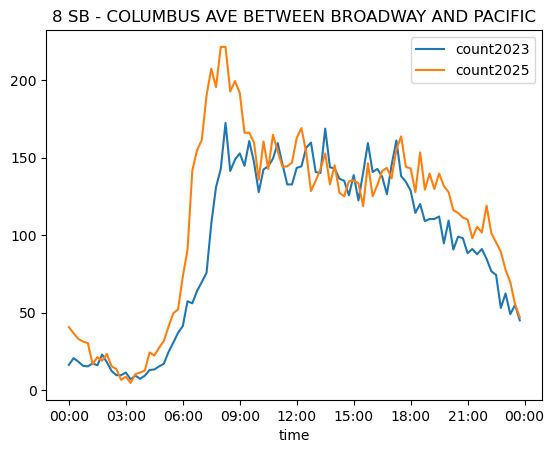

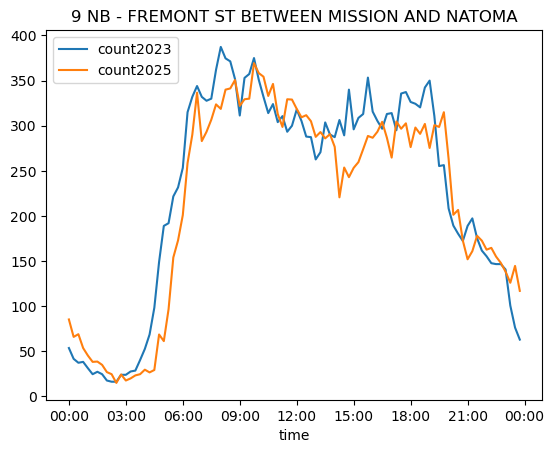

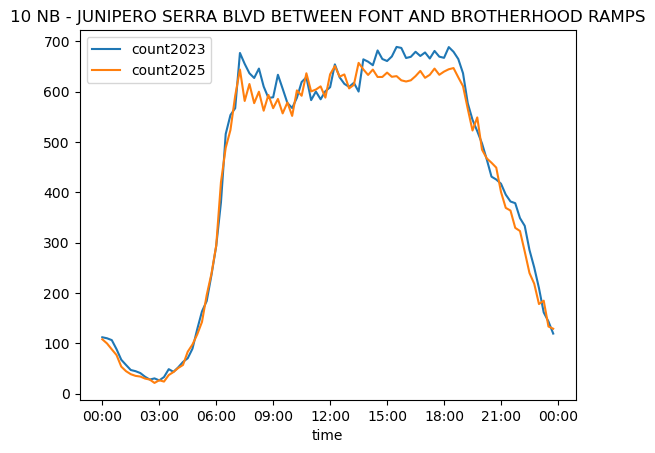

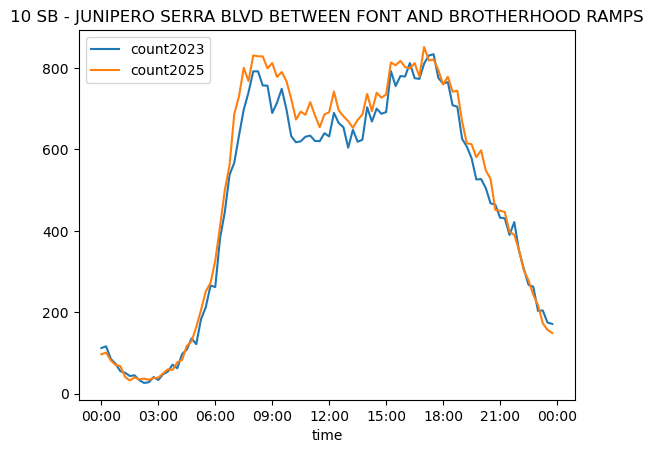

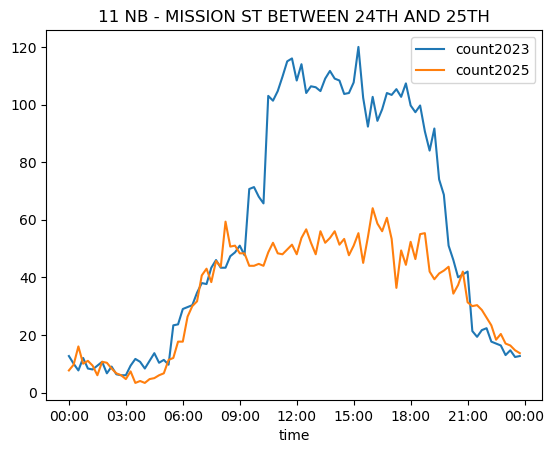

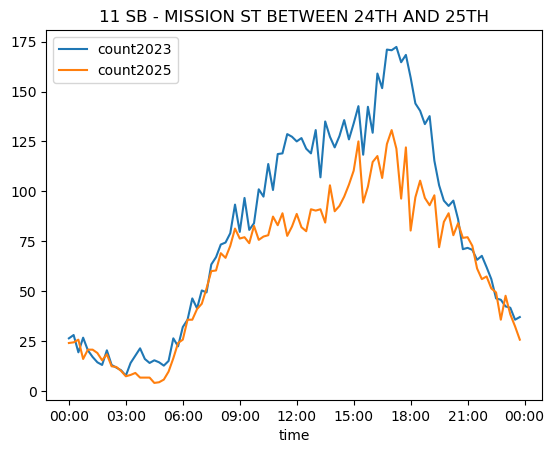

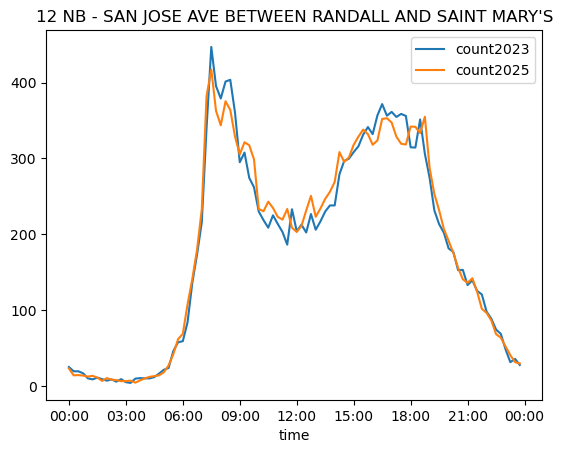

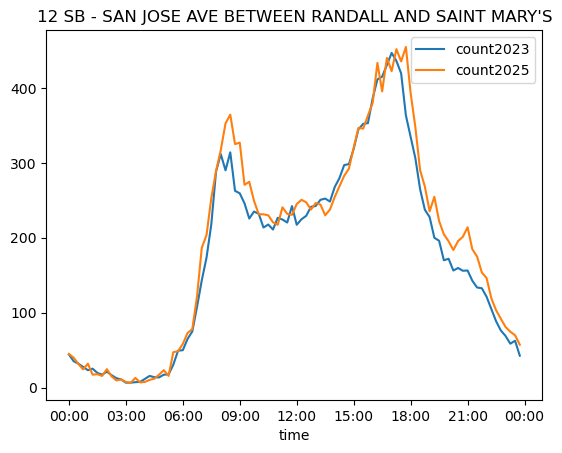

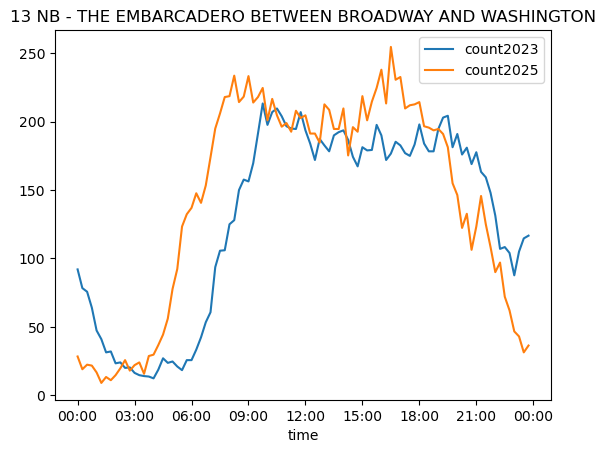

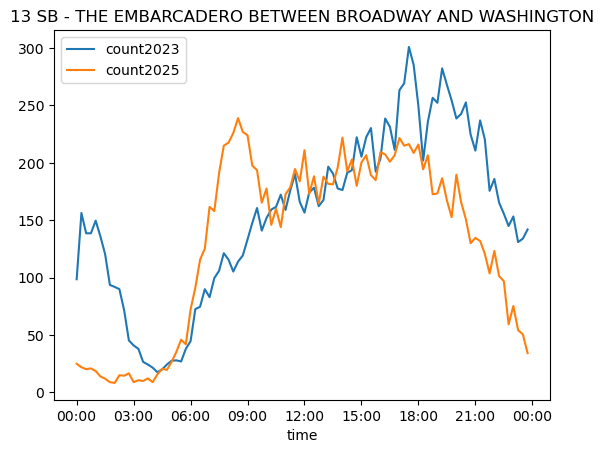

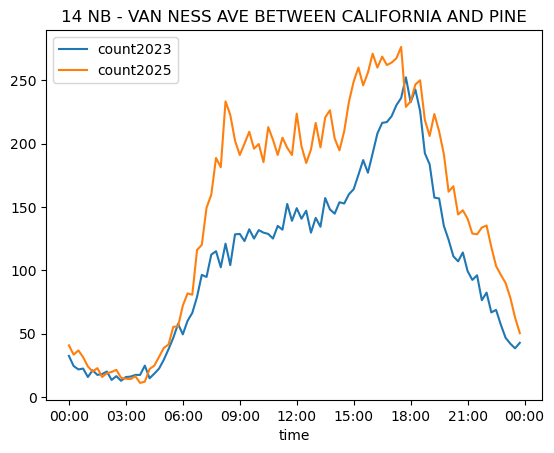

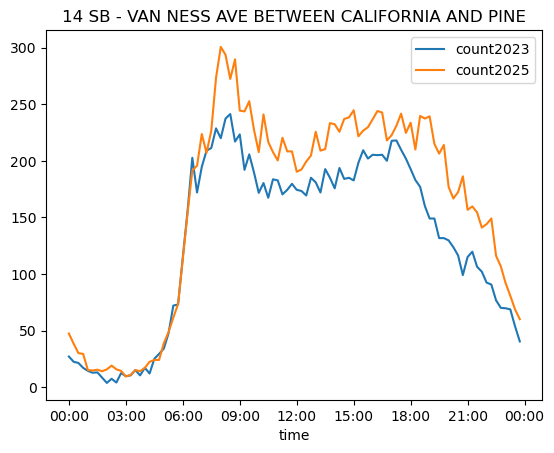

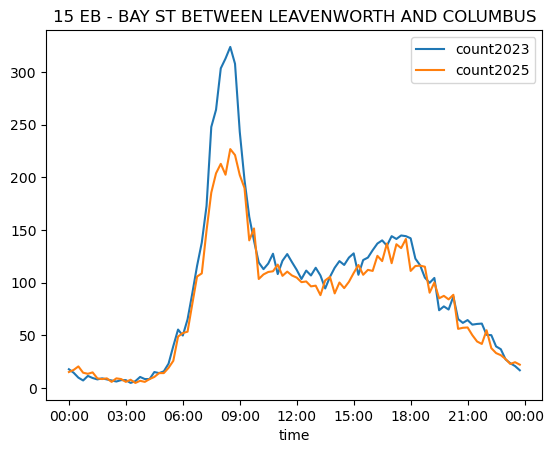

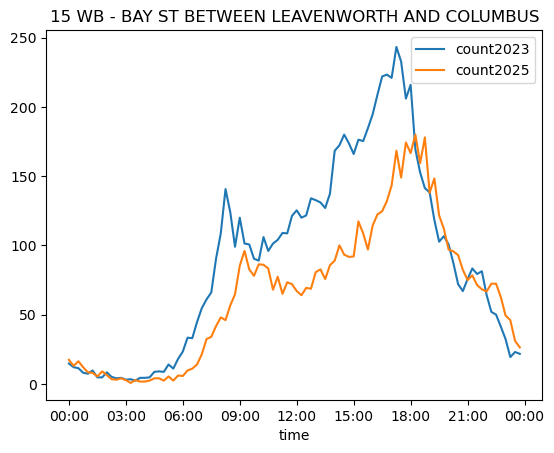

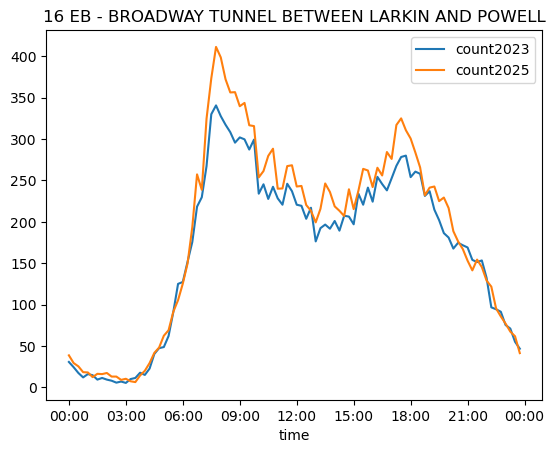

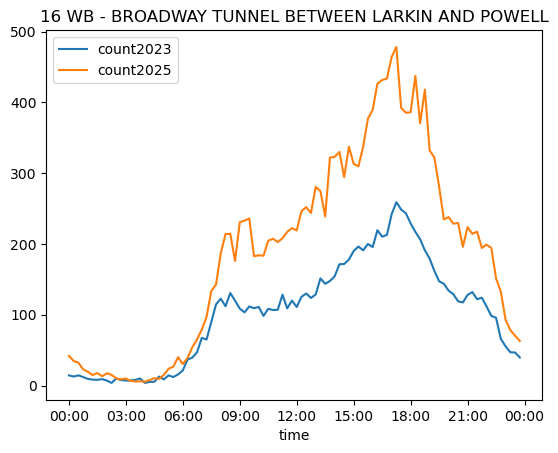

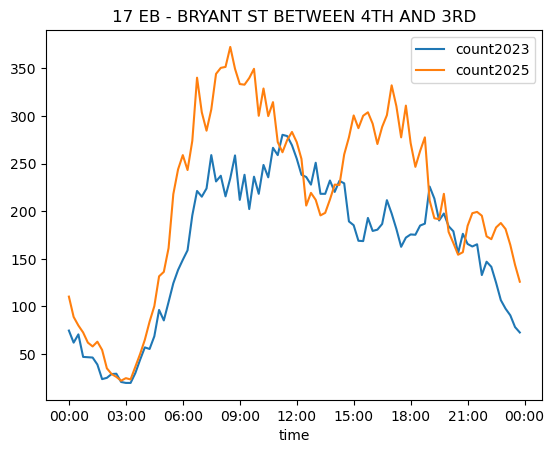

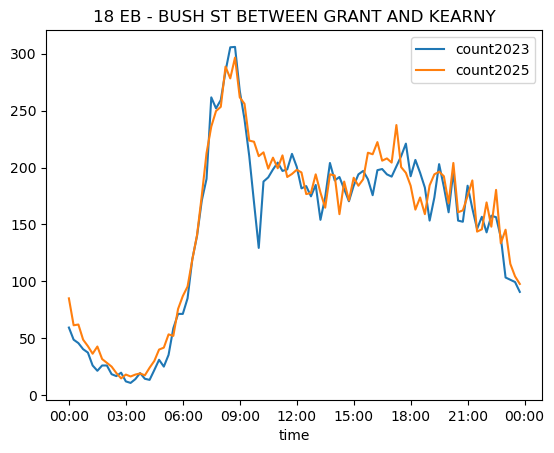

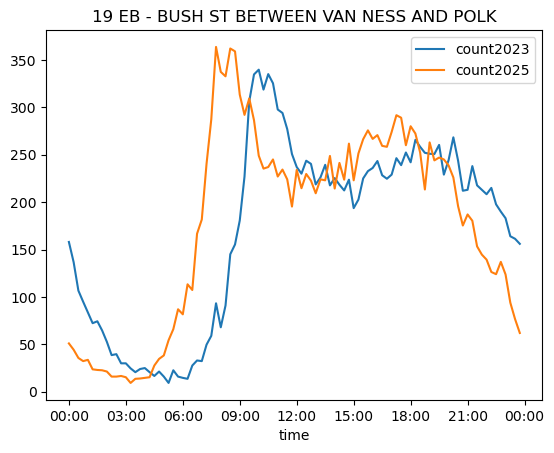

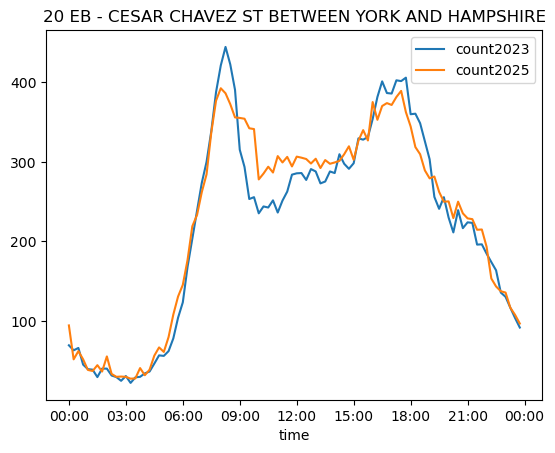

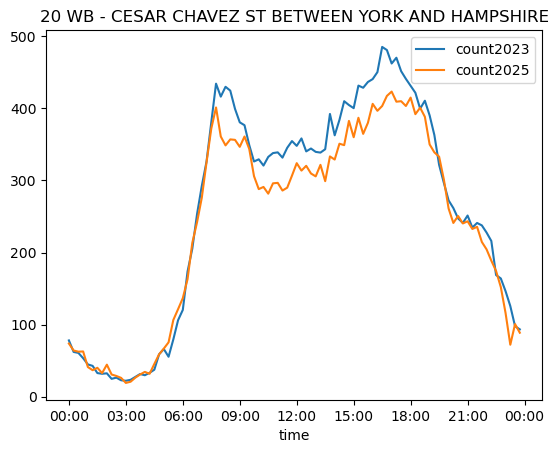

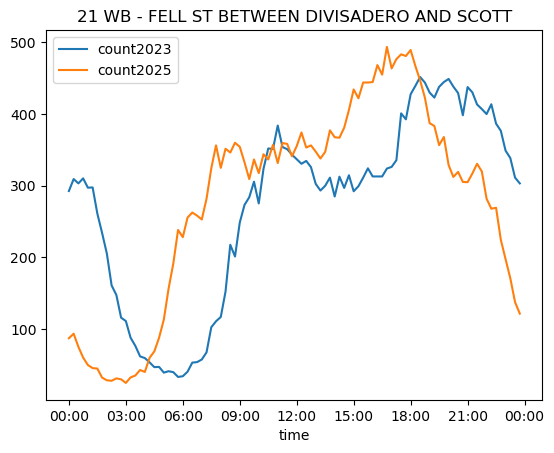

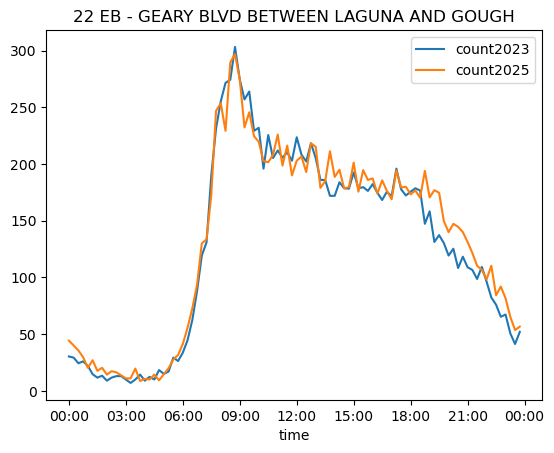

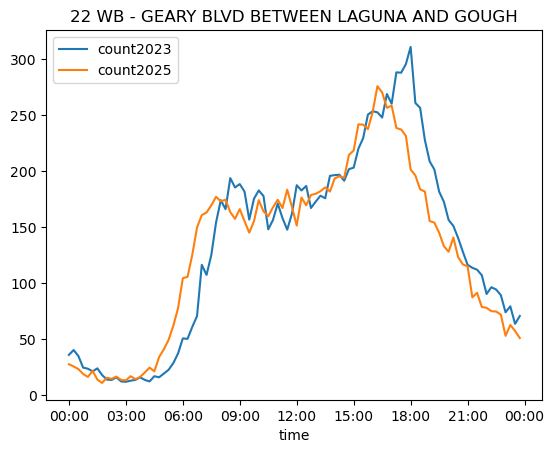

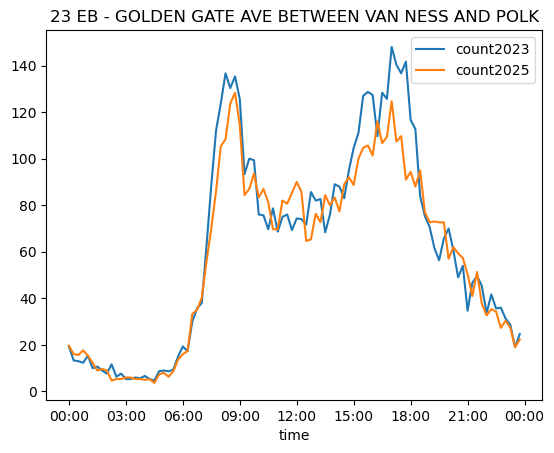

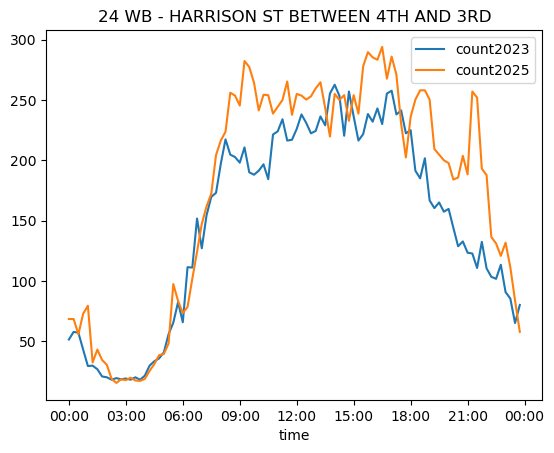

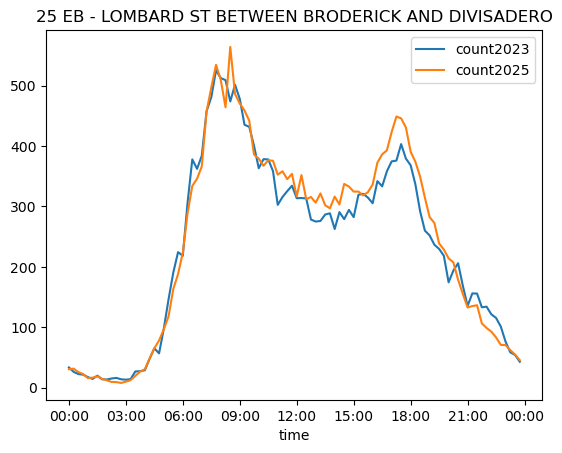

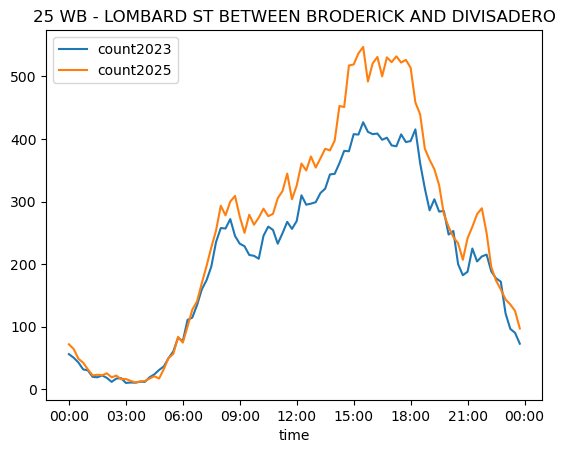

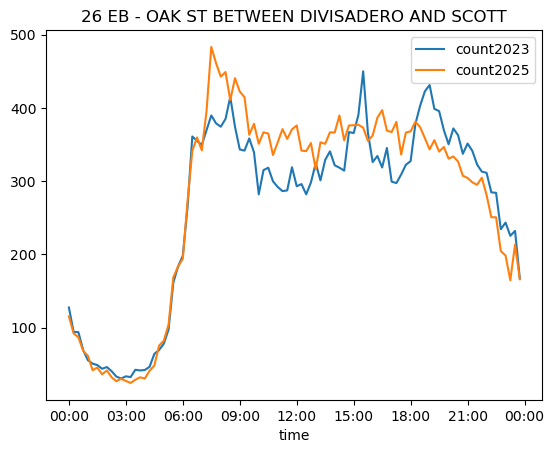

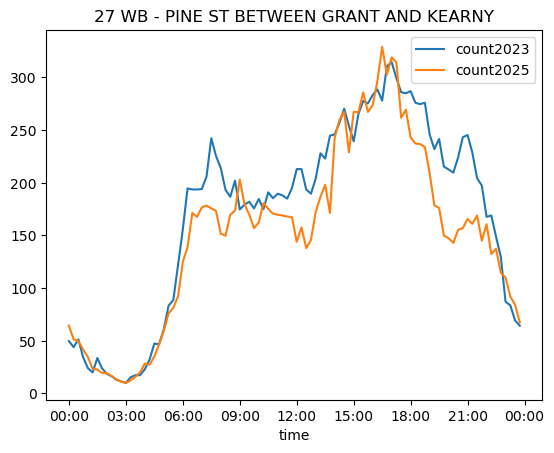

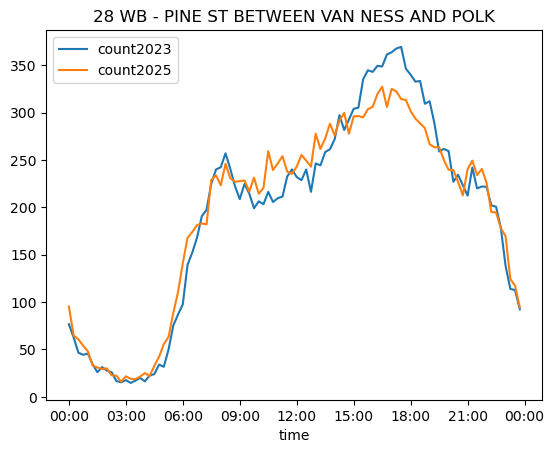

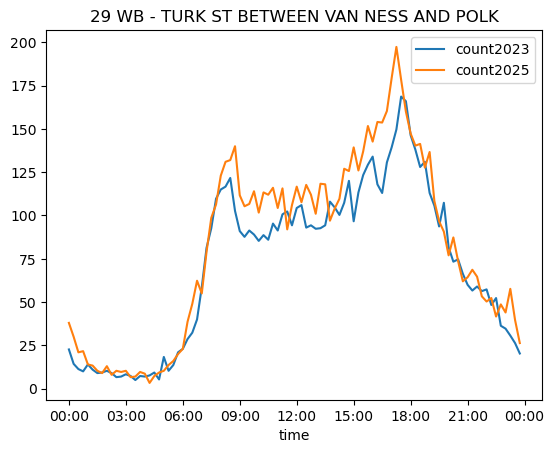

In [29]:
for (id, dir), g in comp.groupby(['location_id','direction']):
    name = locations.loc[(id, dir), 'location_name']
    fig, ax = plt.subplots()
    ax.set_xticks(range(0,24*60*60+1,10800))
    ax.set_title('{} {} - {}'.format(id, dir, name))
    g[['time','count2023','count2025']].plot(x='time', ax=ax)
    
    plt.savefig(OUTDIR / 'figs/15min/{}{}-{} (15 min).jpg'.format(id, dir, name))

C:\Users\drew\AppData\Local\Temp\ipykernel_61584\645336776.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


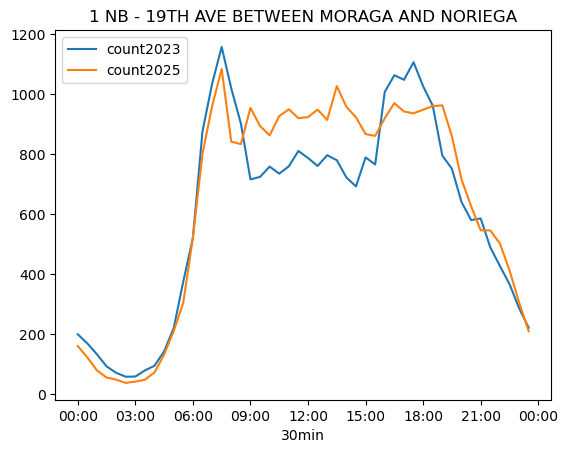

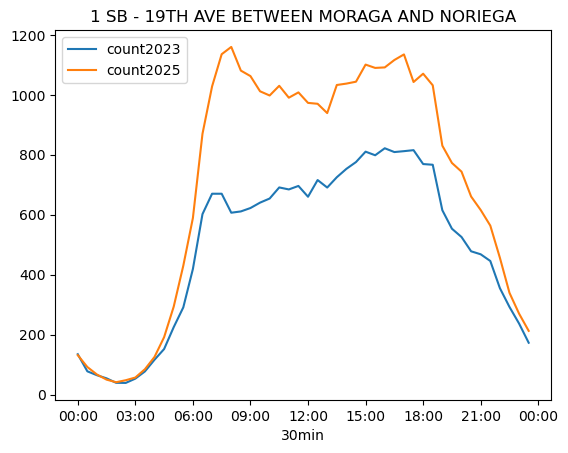

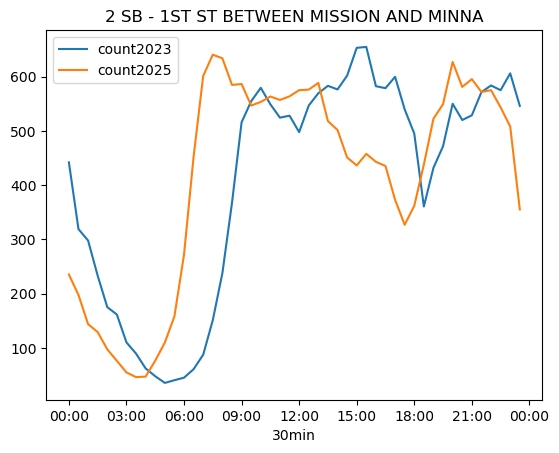

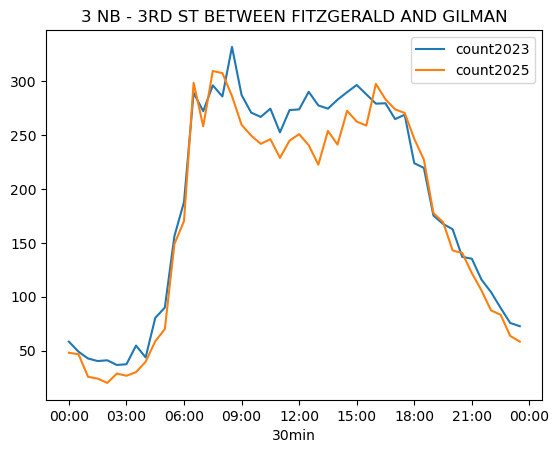

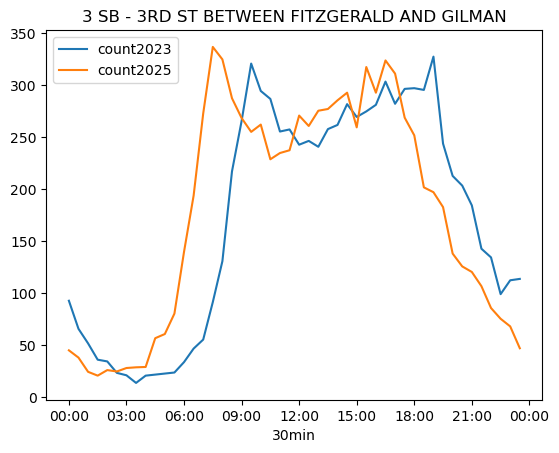

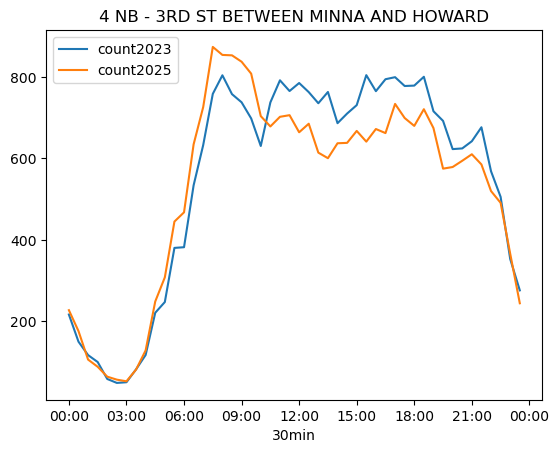

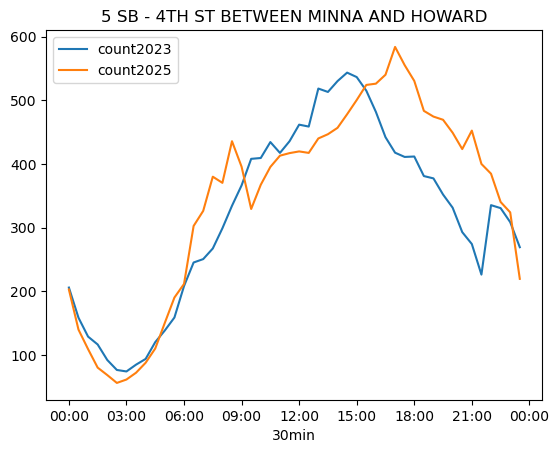

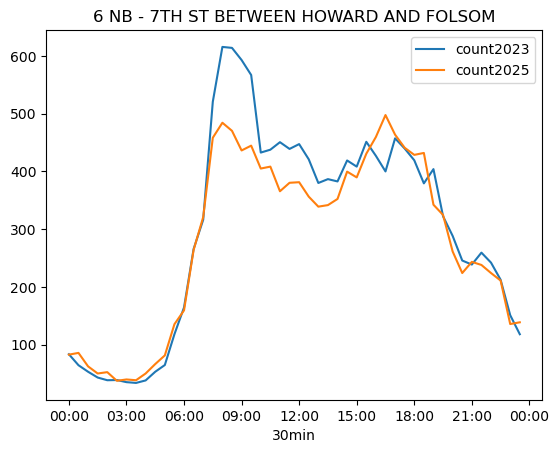

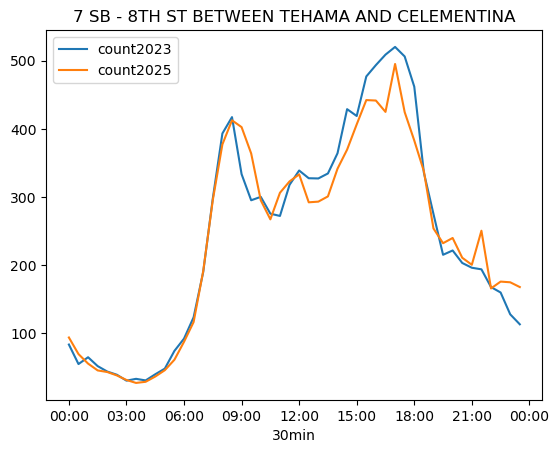

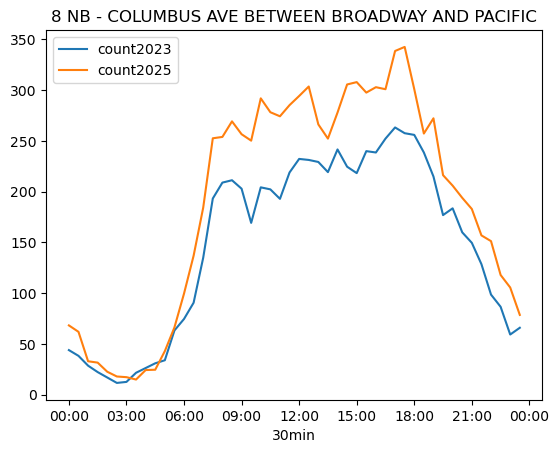

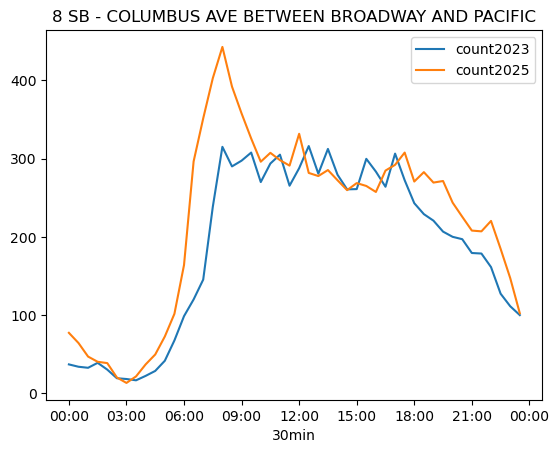

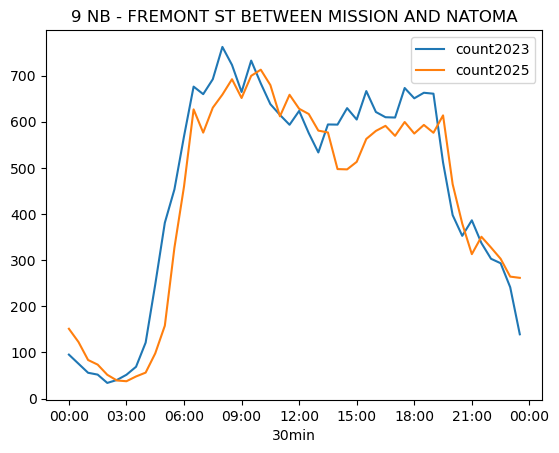

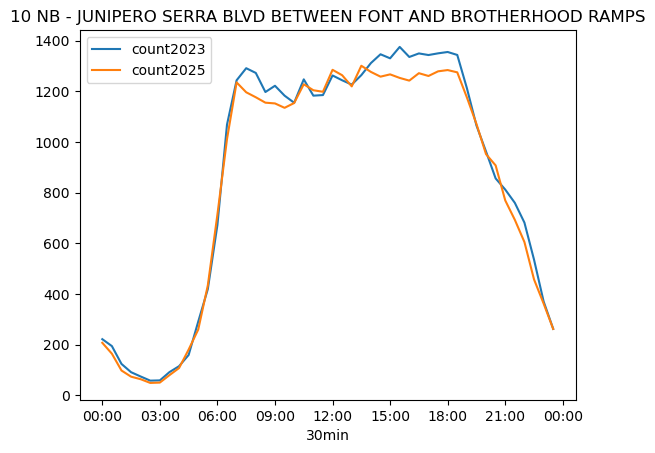

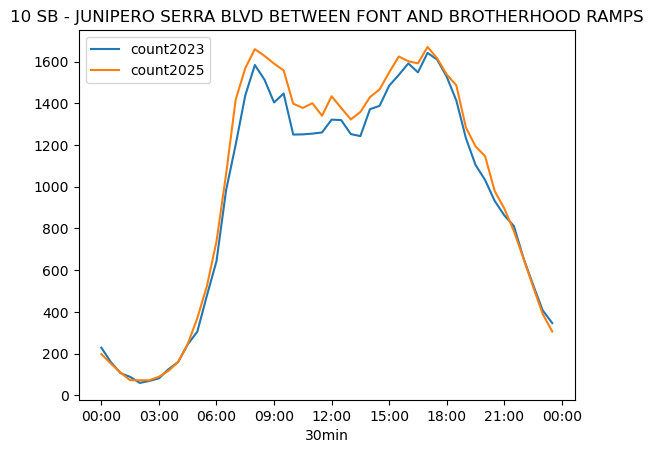

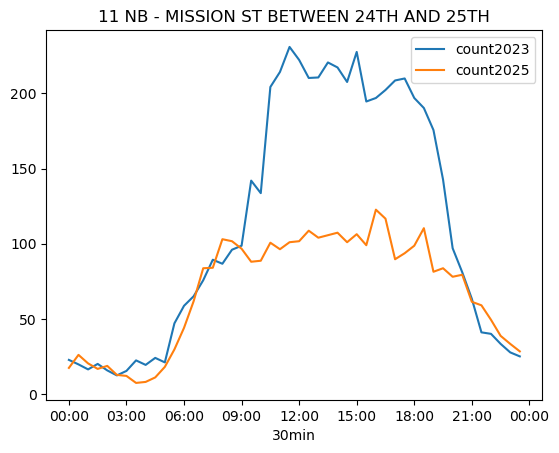

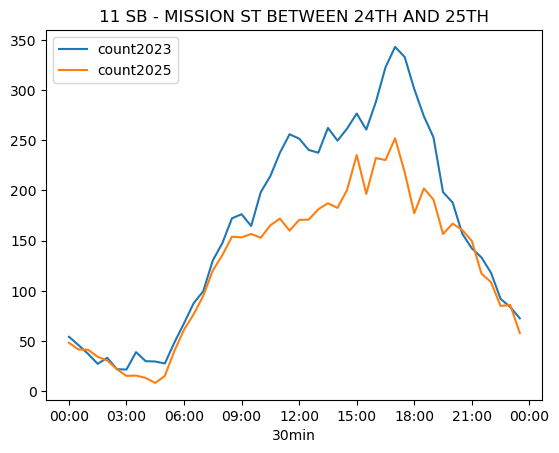

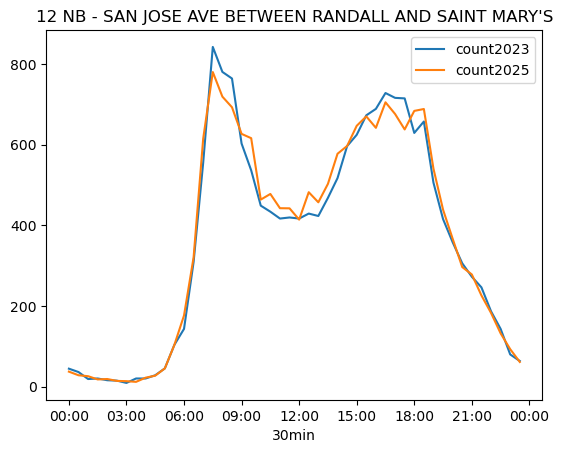

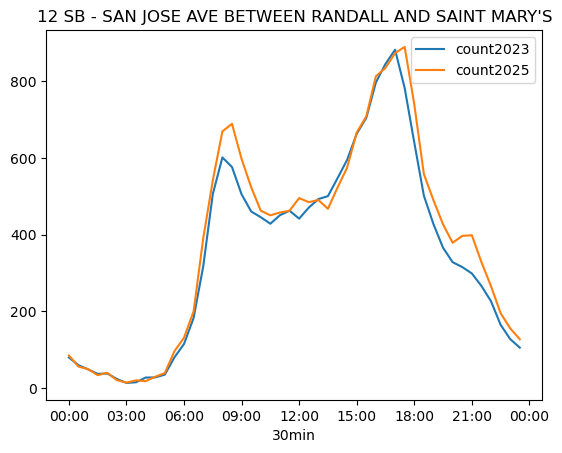

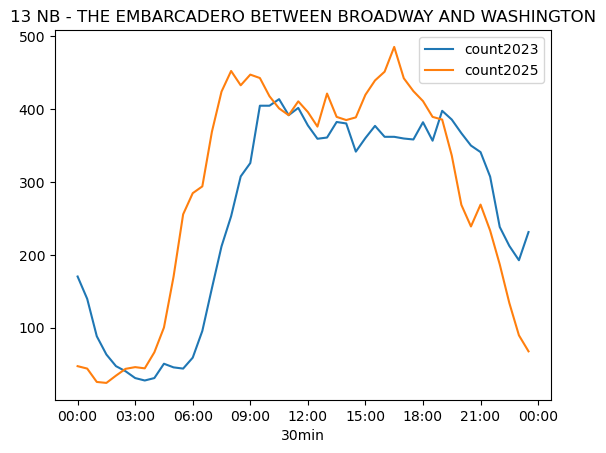

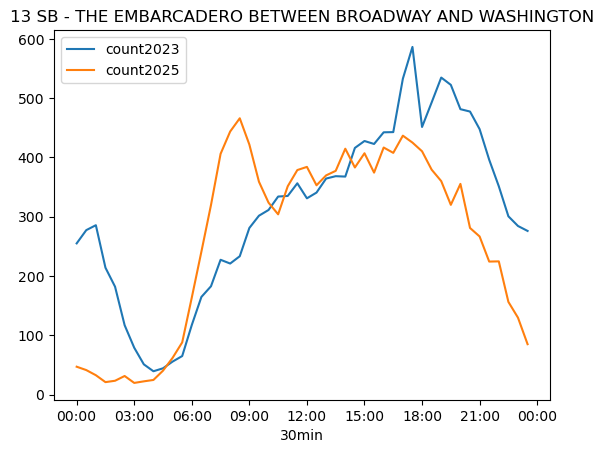

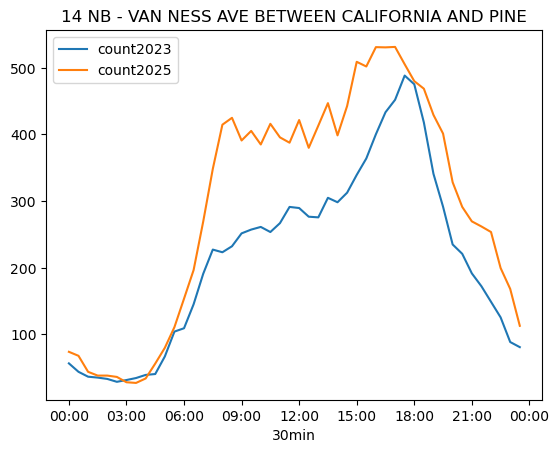

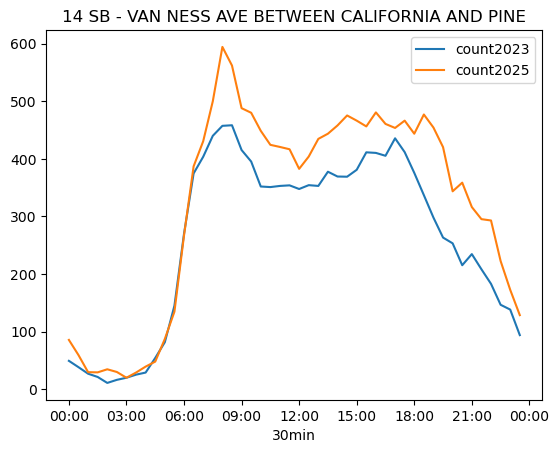

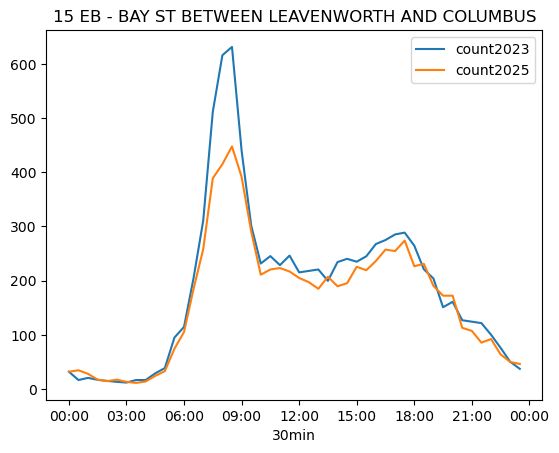

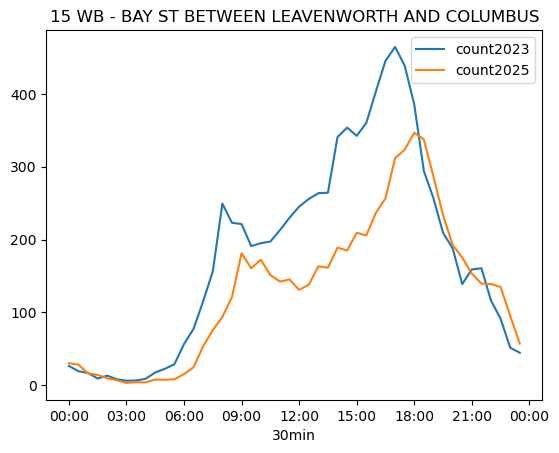

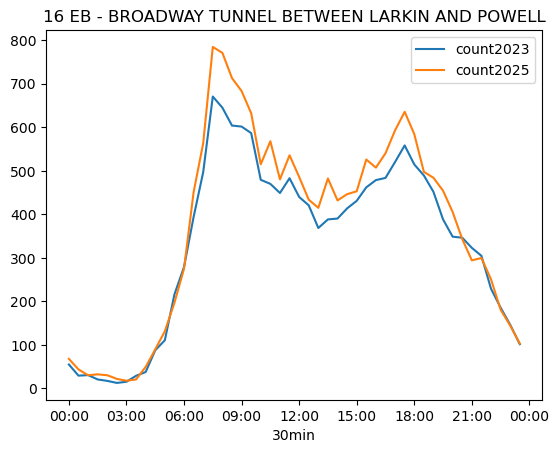

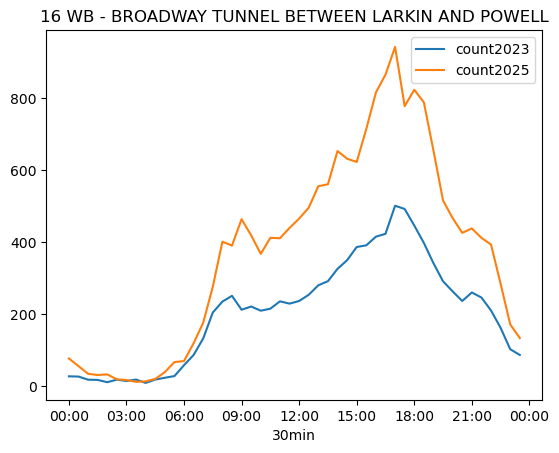

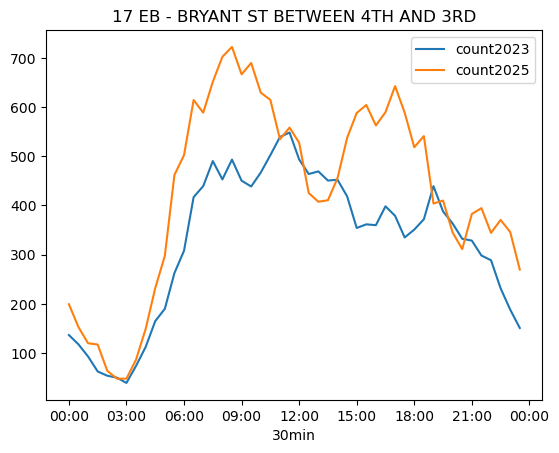

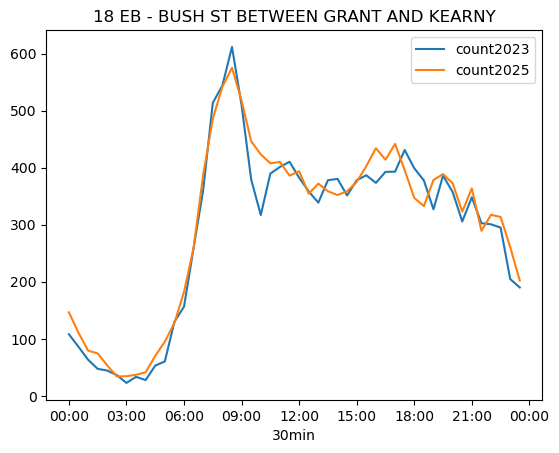

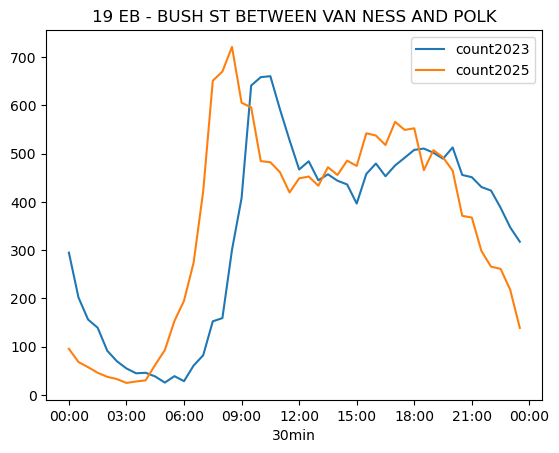

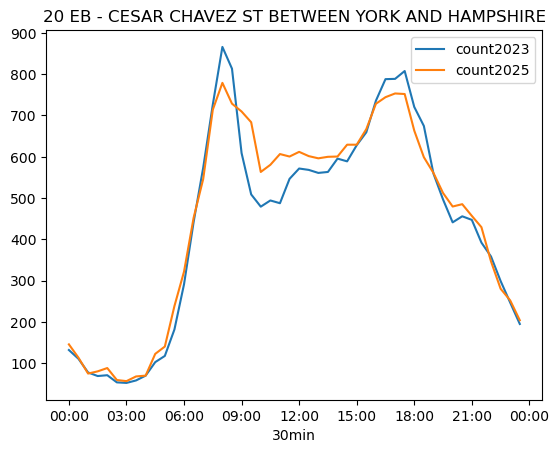

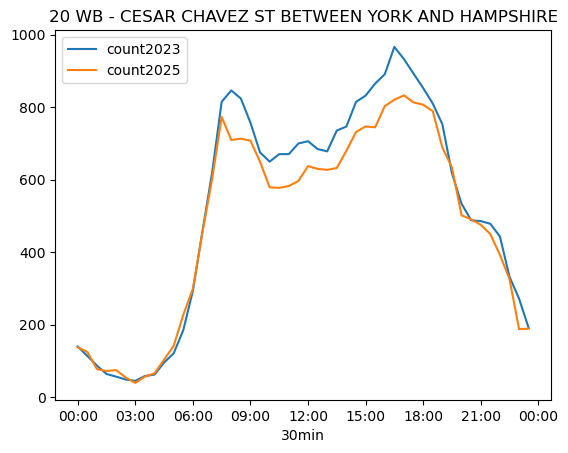

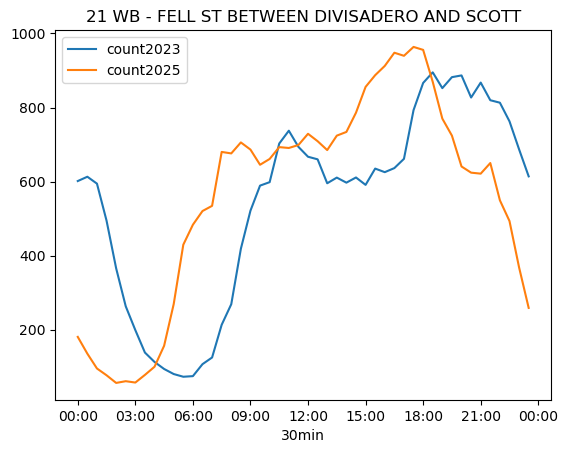

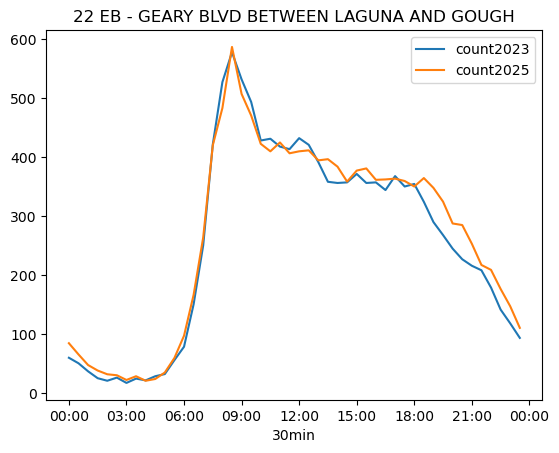

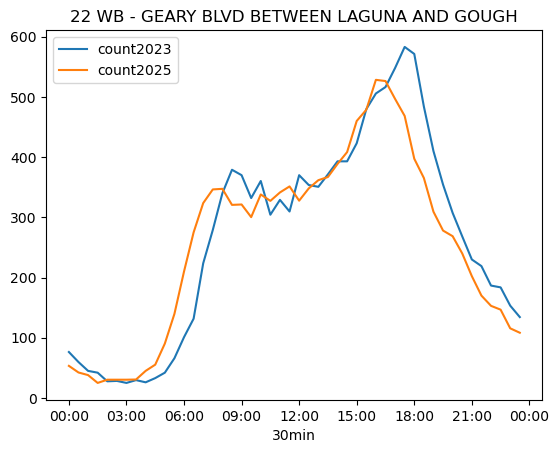

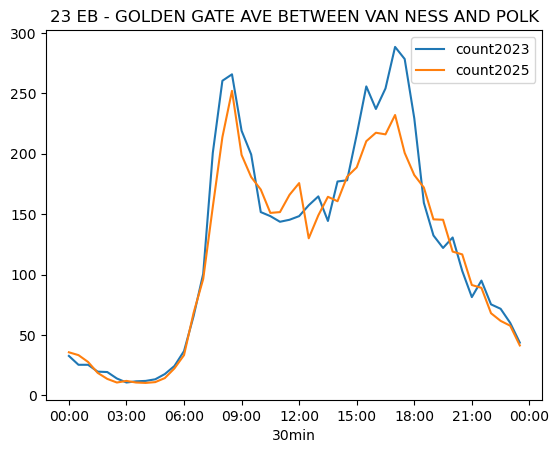

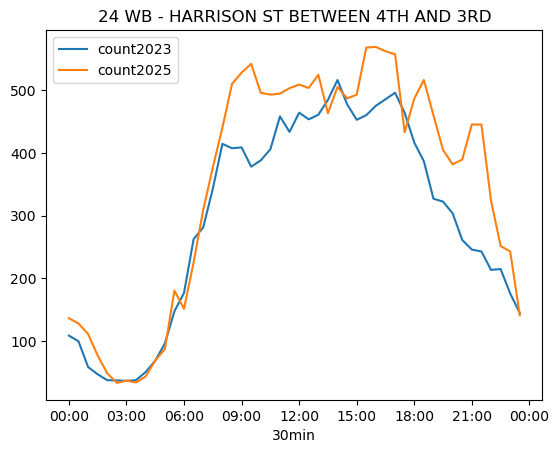

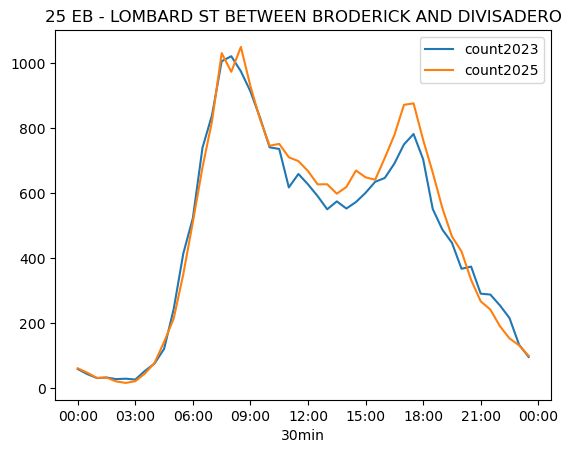

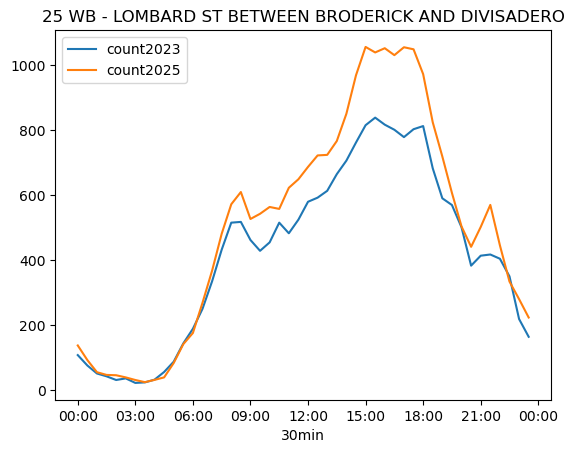

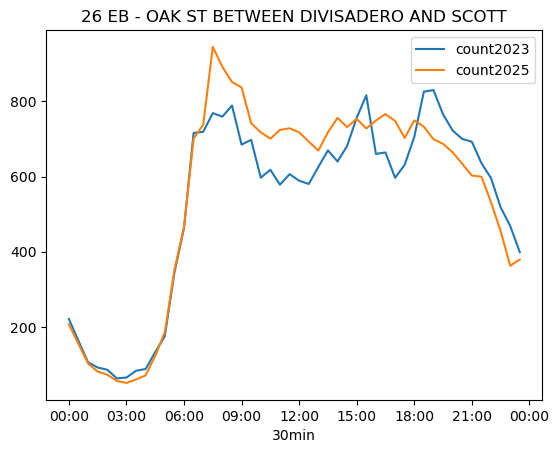

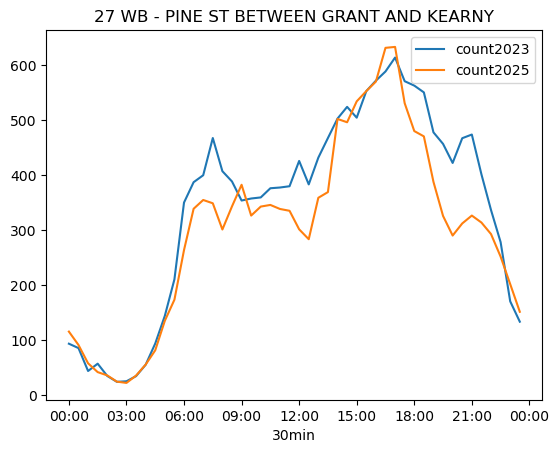

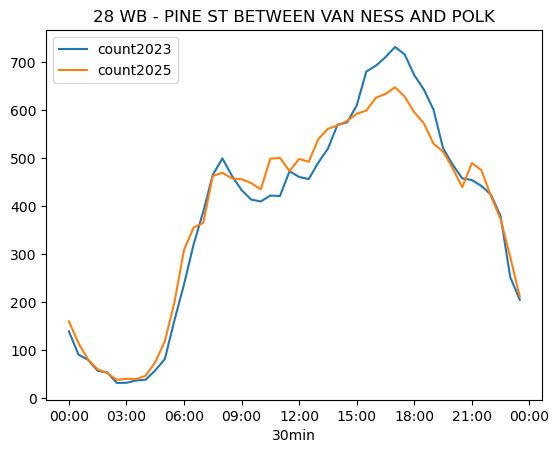

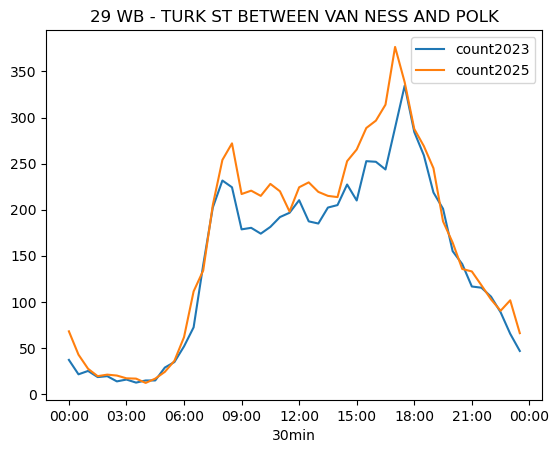

In [30]:
for (id, dir), g in comp30.groupby(['location_id','direction']):
    name = locations.loc[(id, dir), 'location_name']
    fig, ax = plt.subplots()
    ax.set_xticks(range(0,24*60*60+1,10800))
    ax.set_title('{} {} - {}'.format(id, dir, name))
    g[['30min','count2023','count2025']].plot(x='30min', ax=ax)
    
    plt.savefig(OUTDIR / 'figs/30min/{}{}-{} (30 min).jpg'.format(id, dir, name))

C:\Users\drew\AppData\Local\Temp\ipykernel_61584\3419233572.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


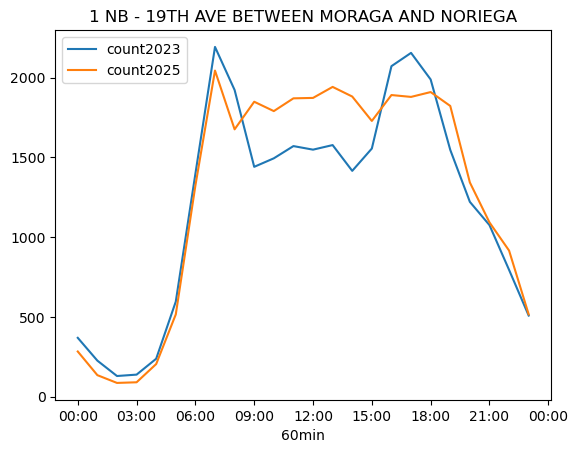

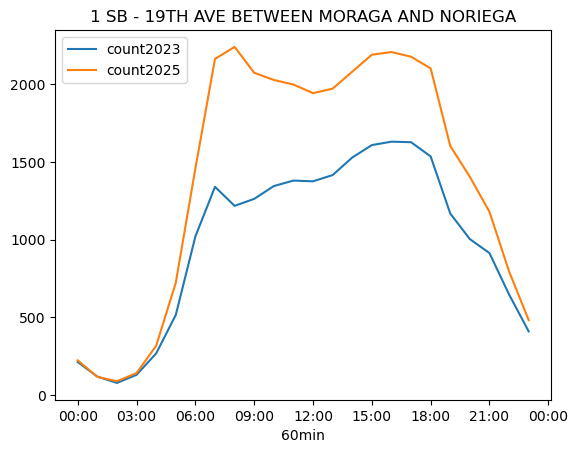

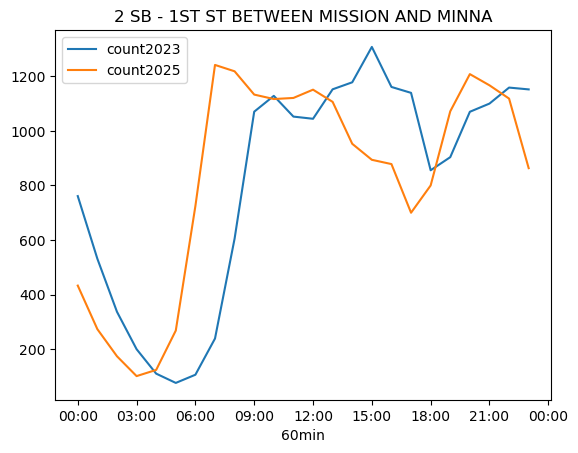

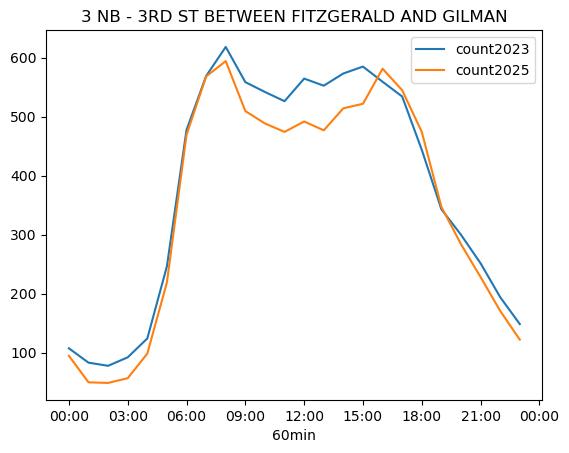

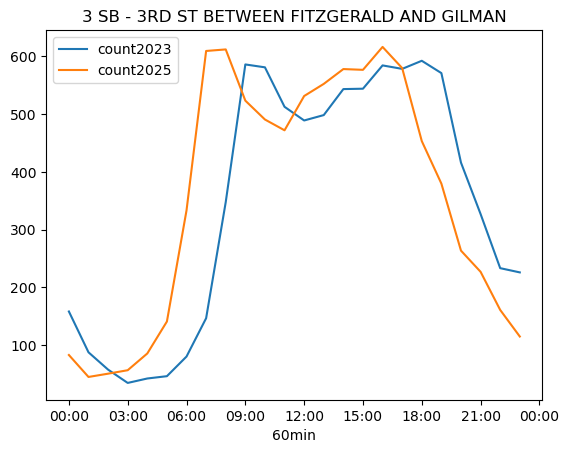

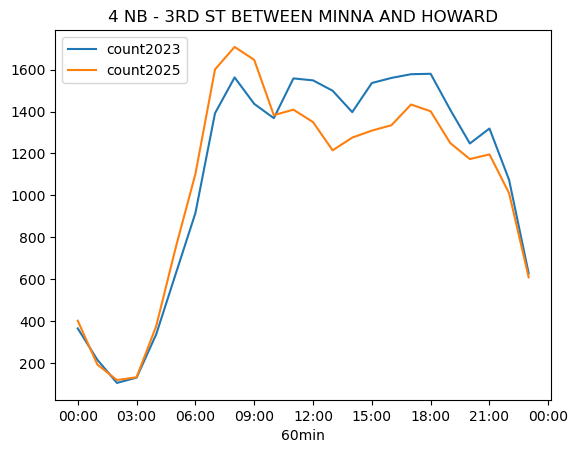

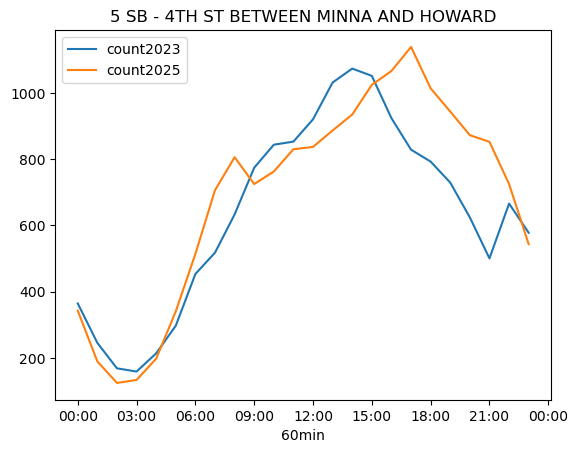

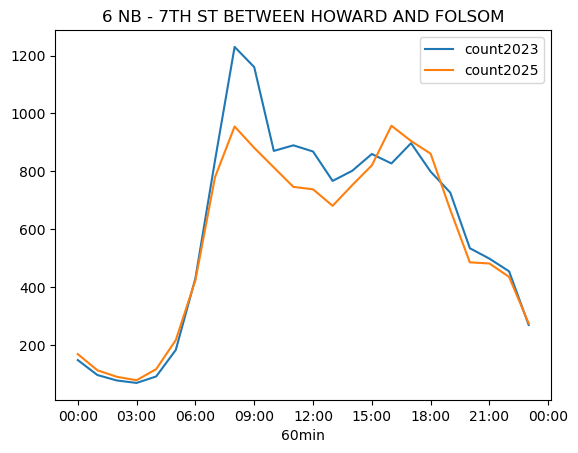

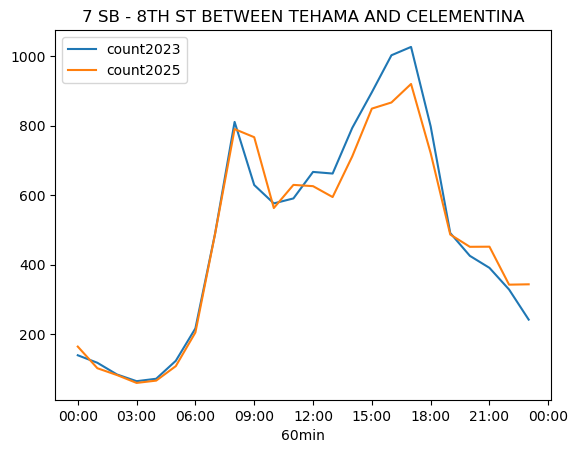

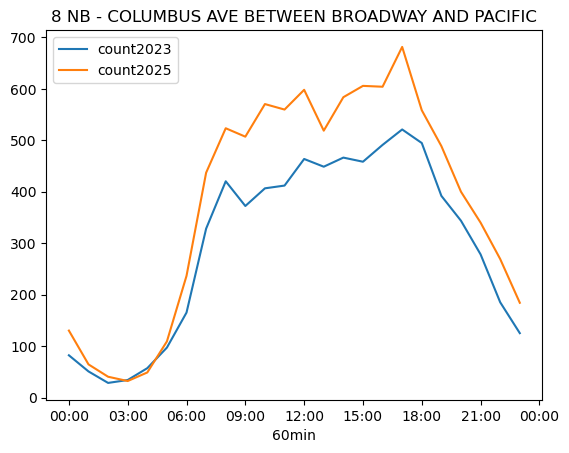

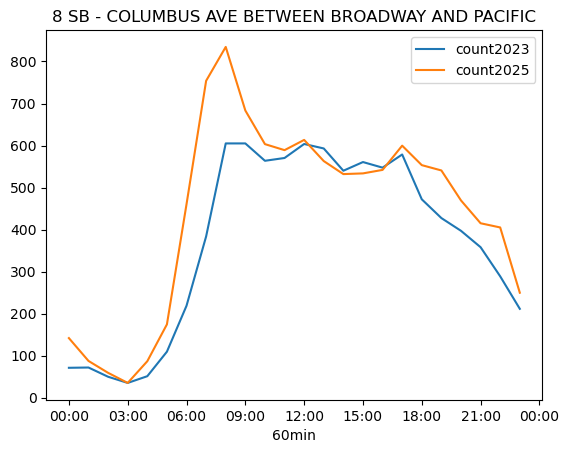

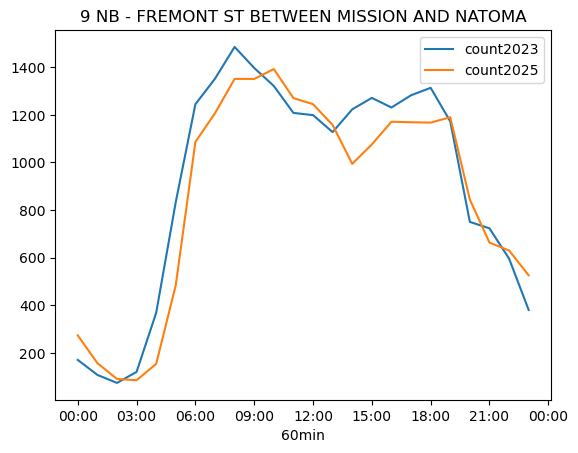

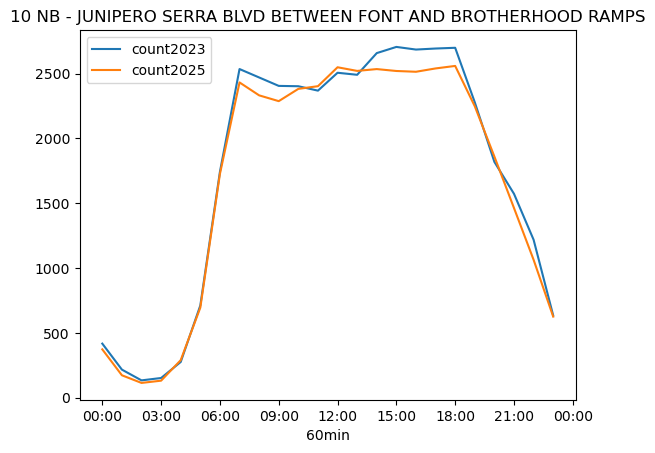

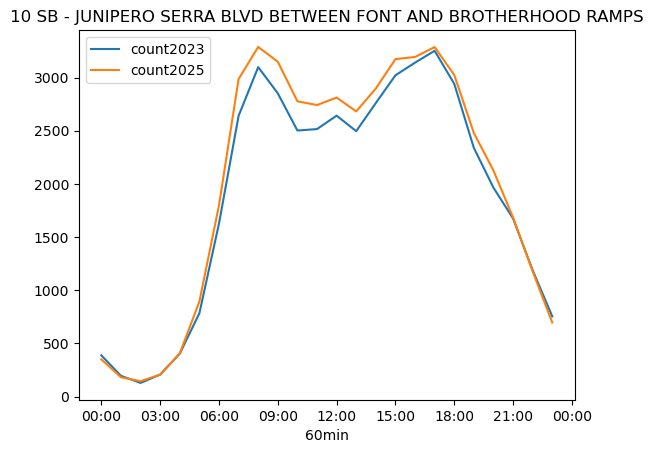

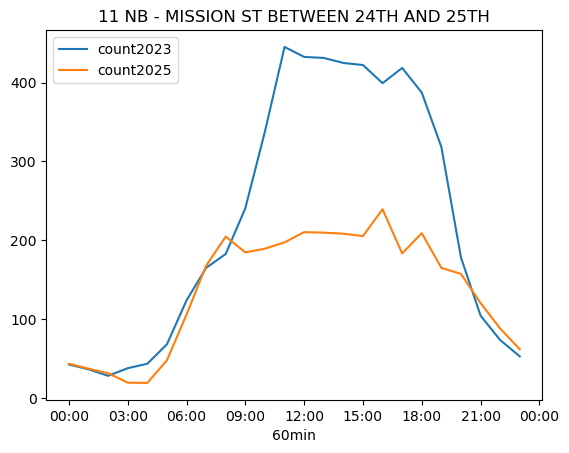

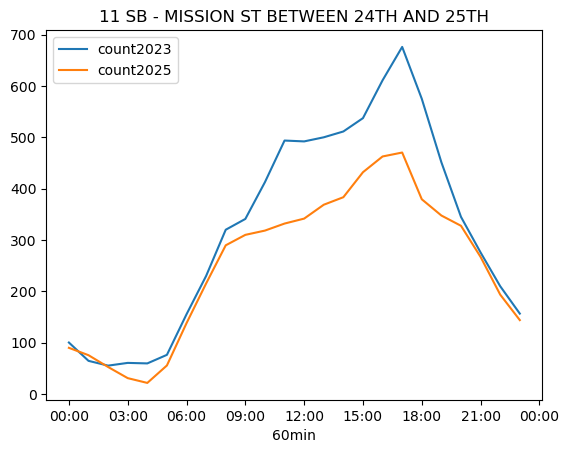

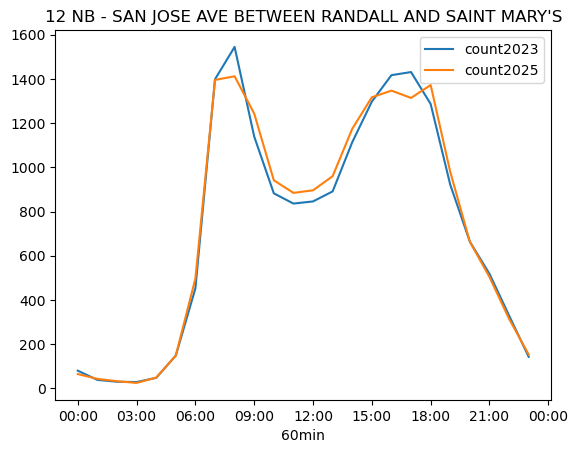

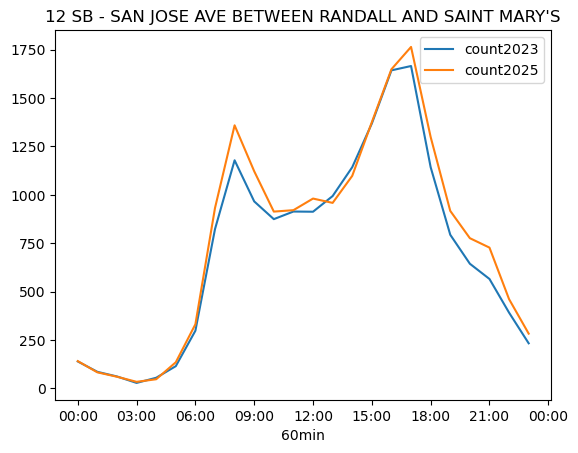

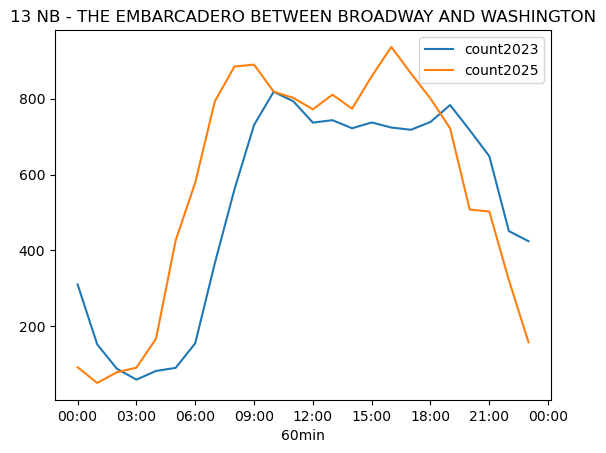

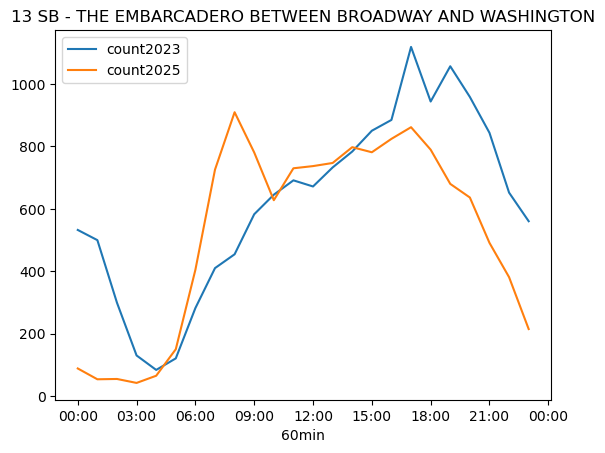

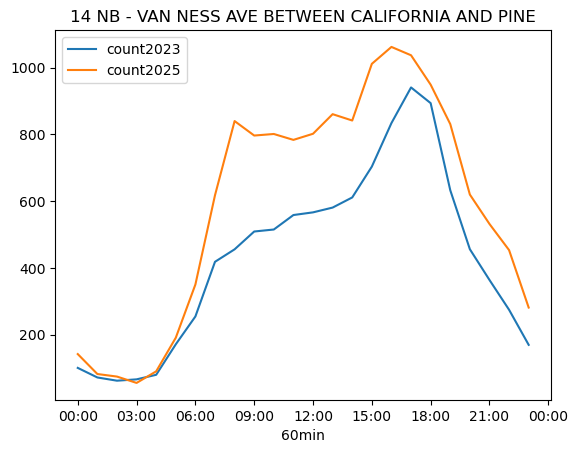

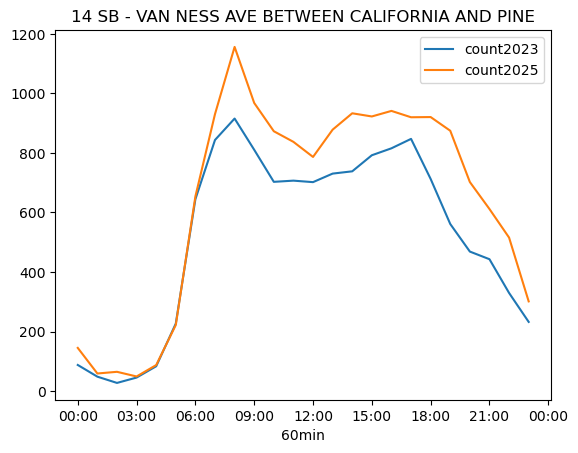

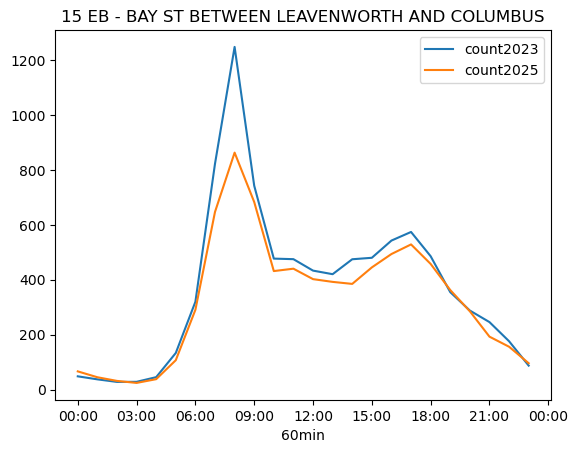

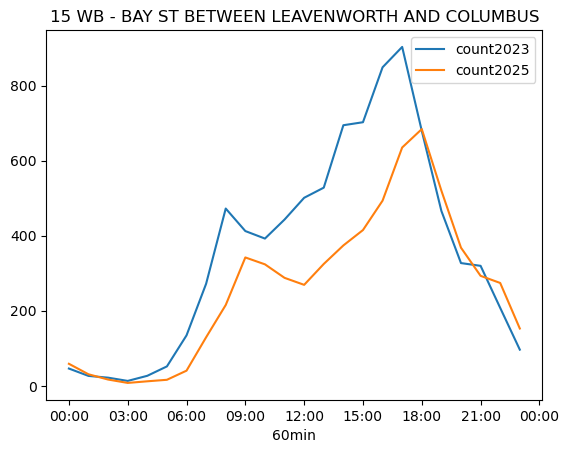

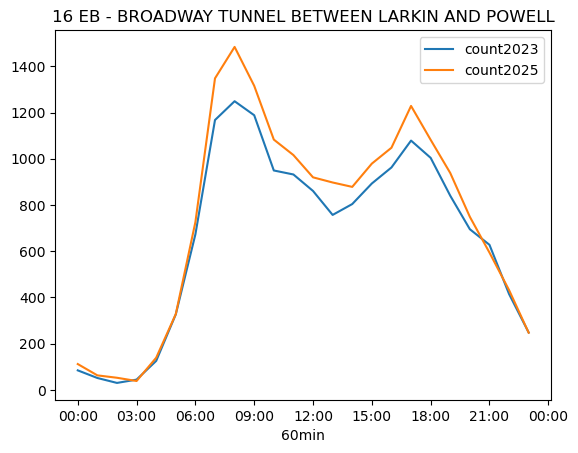

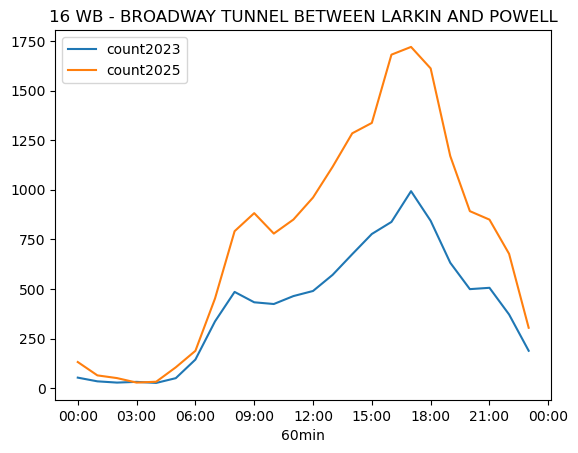

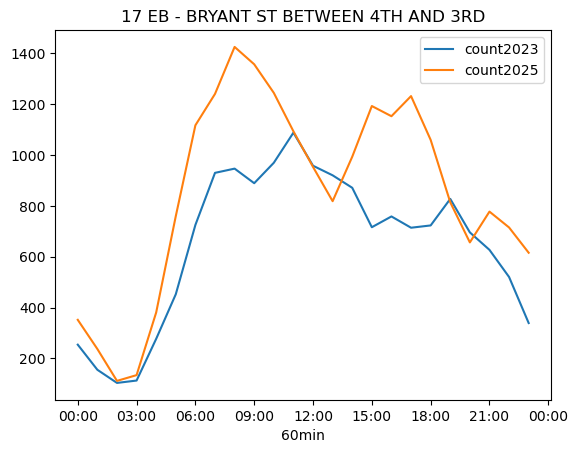

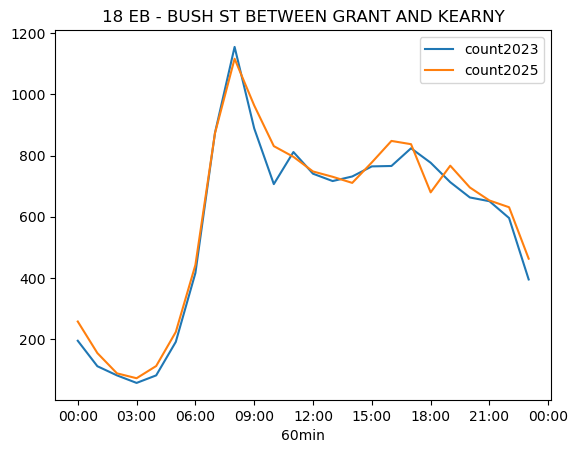

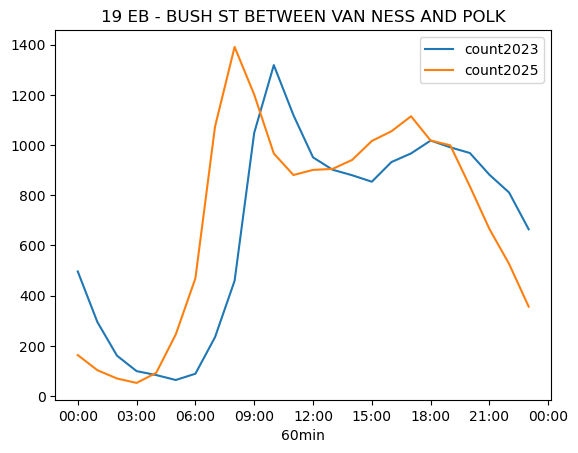

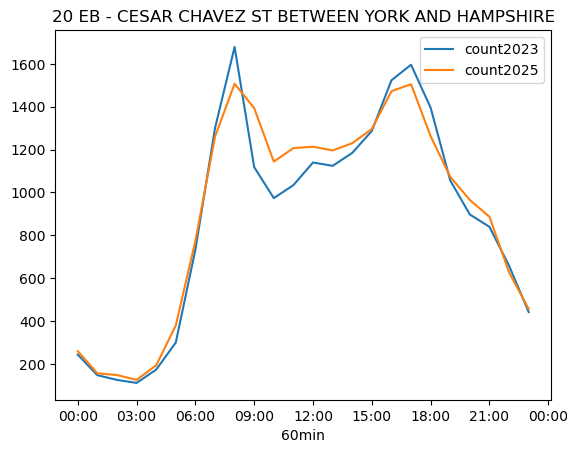

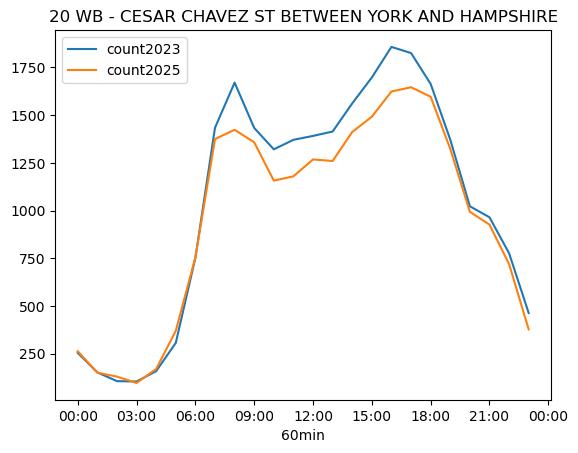

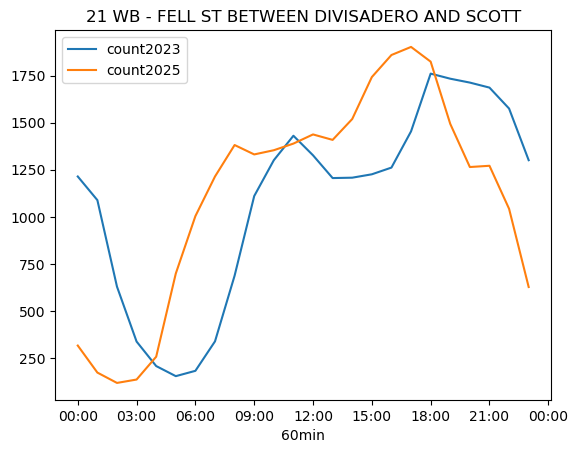

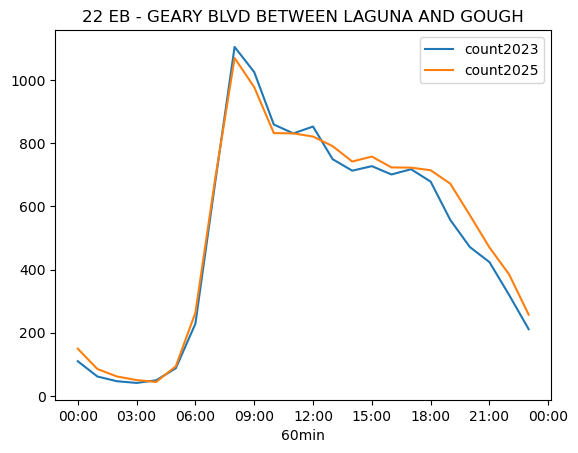

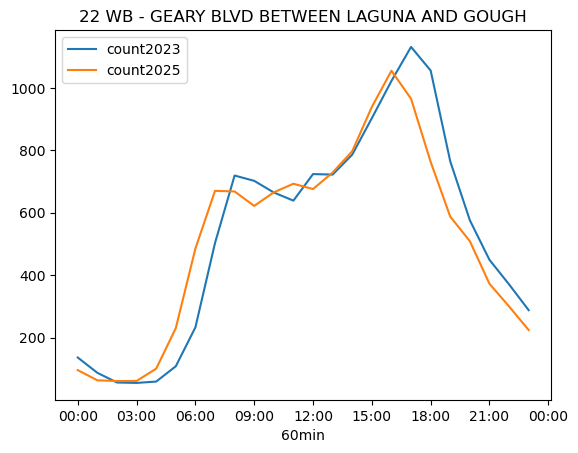

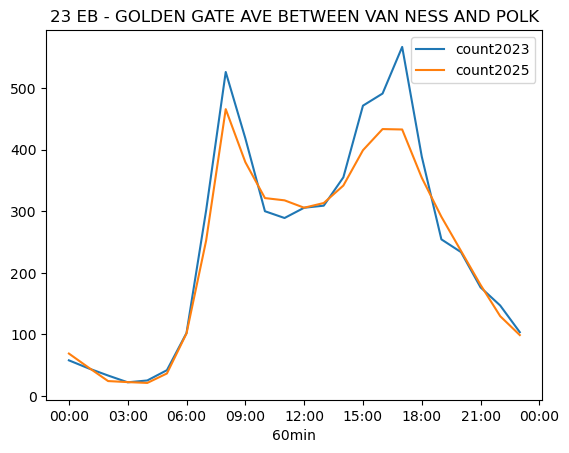

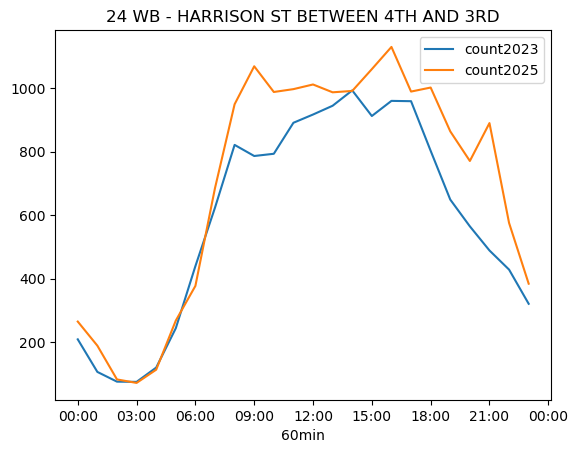

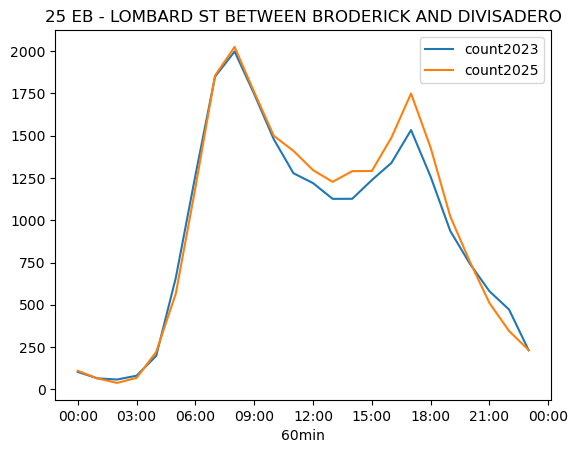

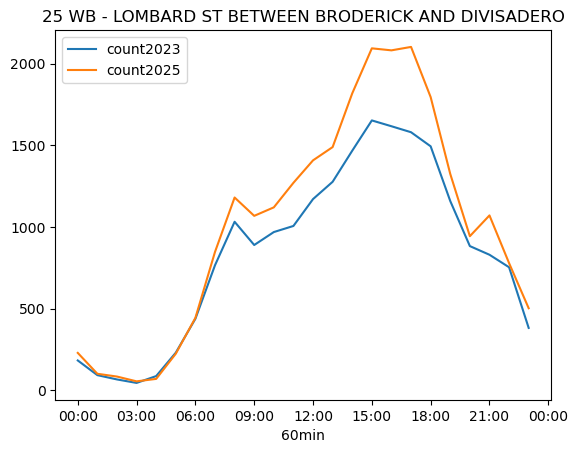

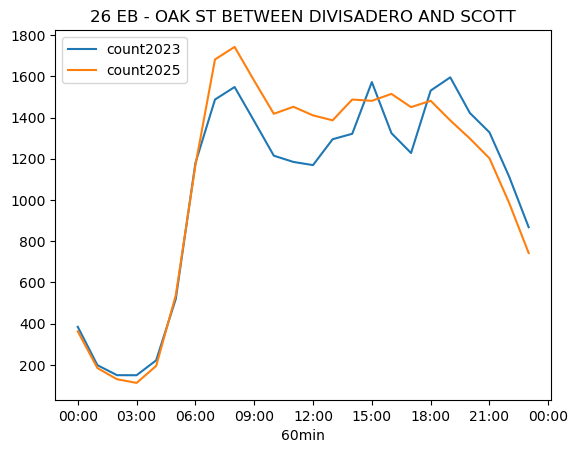

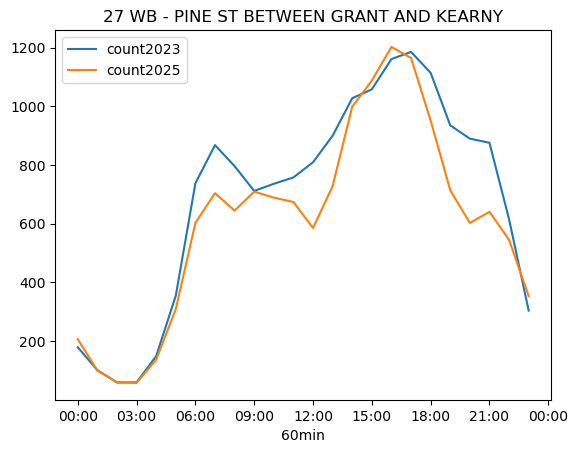

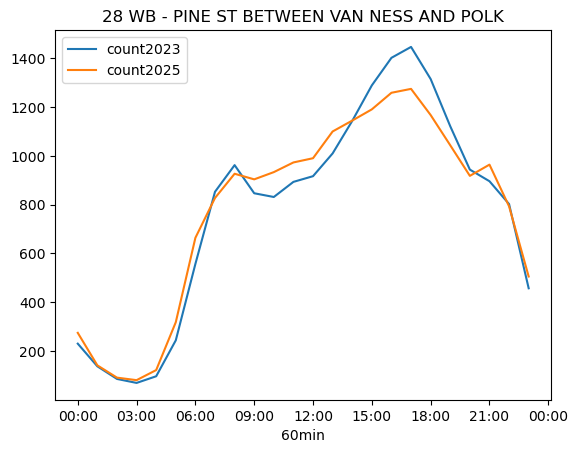

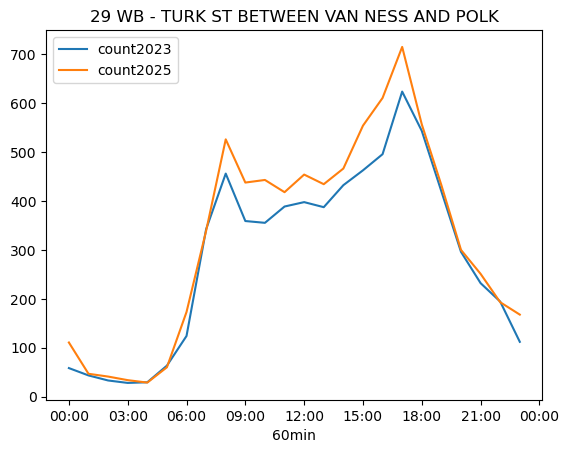

In [31]:
for (id, dir), g in comp60.groupby(['location_id','direction']):
    name = locations.loc[(id, dir), 'location_name']
    fig, ax = plt.subplots()
    ax.set_xticks(range(0,24*60*60+1,10800))
    ax.set_title('{} {} - {}'.format(id, dir, name))
    g[['60min','count2023','count2025']].plot(x='60min', ax=ax)
    
    plt.savefig(OUTDIR / 'figs/60min/{}{}-{} (60 min).jpg'.format(id, dir, name))